# Heavy Equipment Price Prediction
### Regression Analysis using Machine Learning

---


### Table of Contents

1. Problem Statement
2. Import Libraries
3. Dataset Loading
4. Dataset Overview
5. Exploratory Data Analysis
6. Data Cleaning
7. Feature Engineering
8. Data Preprocessing
9. Model Building
10. Hyperparameter Tuning
11. Final Preditions
12. Conclusion

# 1. Problem Statement

### Objective

The objective of this project is to predict the resale price of heavy equipment using historical transaction data.

This is a regression problem,the model learns relationships between equipment characteristics and their selling price.

The evaluation metric for this competition is Root Mean Squared Logarithmic Error (RMSLE),which penalizes large percentage errors while reducing the effect of extremely expensive machinery.

Our goal is to build a machine learning pipeline involving:

- Data exploration
- Data cleaning
- Feature engineering
- Model training
- Hyperparameter tuning
- Final prediction

# 2. Import Libraries

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt 
import seaborn as sns

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_log_error
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
import lightgbm as lgb

# Utilities
import gc
from datetime import timedelta
import os
import kagglehub
for dirname,_,filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname,filename))

sns.set_theme(style="whitegrid",palette="deep")
plt.rcParams["figure.figsize"]=(8,5)

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


# 3. Dataset Loading

This section loads the training and test datasets and performs an initial inspection to understand their dimensions,structure,data types,and overall quality before EDA.

## 3.1 Loading Data

In [2]:
df=pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")
test=pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv")
ss=pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv")

/tmp/ipykernel_23/793756948.py:1: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")


## 3.2 Dataset Dimension

In [3]:
print('Shape of the Training DataSet is:',df.shape)
print('Shape of the Testing DataSet is:',test.shape)

Shape of the Training DataSet is: (138701, 50)
Shape of the Testing DataSet is: (15000, 49)


### Observation

- Training dataset contains both features and the target variable.
- Test dataset contains only the independent variables.
- The large number of samples makes tree-based ensemble models suitable.

## 3.3 Dataset preview

In [4]:
## checking heads
df.head().T

,0,1,2,3,4
TransactionID,1139309,1139316,1139317,1139322,1139333
TargetValue,57000.0,26500.0,21000.0,27000.0,21500.0
AssetID,117665,1001282,772709,902010,1036259
ProductConfigID,88,4616,1948,3550,36014
DataOriginCode,ACH138,ACH138,ACH138,ACH138,ACH138
VendorPartnerID,GTX,GTX,GTX,GTX,GTX
ManufactureYear,1997,2005,1994,2002,2009
OperationalHoursMeter,4640.0,508.0,11540.0,4883.0,302.0
UtilizationTier,Low,Low,High,High,Low
TransactionDate,2005-03-26,2009-12-18,2005-08-26,2006-11-17,2010-08-27


### Observation

The dataset consists of numerical and categorical features describing machinery specs,operational details,and transaction information. The target variable is `TargetValue`.

In [5]:
## checking tails
df.tail().T

,138696,138697,138698,138699,138700
TransactionID,6333405,6333406,6333408,6333409,6333410
TargetValue,10000.0,10500.0,12500.0,10000.0,13000.0
AssetID,1919209,1882130,1944221,1794526,1944751
ProductConfigID,21446,21447,21446,21446,21447
DataOriginCode,FFA166,FFA166,FFA166,FFA166,FFA166
VendorPartnerID,MPF,MPF,MPF,MPF,MPF
ManufactureYear,2006,2006,2006,2007,2007
OperationalHoursMeter,NaN,NaN,NaN,NaN,NaN
UtilizationTier,NaN,NaN,NaN,NaN,NaN
TransactionDate,2013-03-07,2013-01-28,2013-01-28,2013-03-07,2013-01-28


## 3.4 Dataset info

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [7]:
df.columns

Index(['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID',
       'DataOriginCode', 'VendorPartnerID', 'ManufactureYear',
       'OperationalHoursMeter', 'UtilizationTier', 'TransactionDate',
       'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass',
       'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor',
       'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory',
       'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3',
       'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9',
       'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col18',
       'col19', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27',
       'col28', 'col29', 'col30'],
      dtype='object')

### Observation

- Dataset contains both numerical and categorical features.
- Several columns contain missing values.
- Appropriate preprocessing will therefore be required before training.

## 3.5 Statistical summary

In [8]:
df.drop(['TransactionID','AssetID','ProductConfigID','ManufactureYear'],axis=1).describe()

,TargetValue,OperationalHoursMeter
count,138701.000000,8.205800e+04
mean,41521.874047,4.553719e+03
std,26361.125948,2.792204e+04
min,7500.000000,0.000000e+00
25%,20500.000000,0.000000e+00
50%,35000.000000,1.620000e+03
75%,57000.000000,5.001000e+03
max,142000.000000,1.729600e+06


In [9]:
df.describe(include='object').T

,count,unique,top,freq
DataOriginCode,138701,6,ADI149,59541
VendorPartnerID,138701,31,UJF,67828
UtilizationTier,50475,3,Medium,24588
TransactionDate,138701,3676,2010-02-16,1159
Spec_FullDescriptor,138701,3505,140G,3751
Spec_BaseClass,138701,1249,12,5702
Spec_SubClass,101716,147,G,17381
Spec_ReleaseSeries,32896,113,II,8425
Spec_VariantModifier,52332,132,L,14496
AssetScaleFactor,97491,6,Large / Medium,39222


### Observation

- Numerical features vary considerably in scale.
- Certain variables contain significant outliers.
- Some variables exhibit strong skewness,motivating feature engineering and robust tree-based models.

## 3.6 Data integrity check
The integrity of the dataset is verified by checking duplicate records,missing values,and overall consistency before performing any preprocessing.

In [10]:
df.duplicated().any()

np.False_

In [11]:
df['TransactionID'].duplicated().any()

np.False_

## 3.7 Initial observations

From the above,the following points can be observed:
- We observe 138701 samples of 49 features in training data,mathematically each sample x_i ~ R^49 dimension
- TargetValue is our target variable depending upon 49 variables,mathematically each sample y_i is a scalar with Y ~ R^d
- df.info() suggest there are many null values in the dataframe,thus they should be treated well(done later)
- We also observe no anomaly in data i.e.,there is no repeated transaction ids,and no sample being repeated.

# 4. Data Overview

This section provides a high-level understanding of the dataset by examining missing values,feature cardinality,and the target variable. These insights help identify potential data quality issues and guide preprocessing decisions before exploratory analysis.

## 4.1 Missing Values Analysis

Missing values can affect model performance and influence the choice of preprocessing techniques. This subsection summarizes the extent of missing data across all features.

### Missing Value Summary

In [12]:
dic=dic={'Feature':[],'Missing Count':[],'Missing %':[]}
null_counts=df.isnull().sum()
for col in df.columns:
    if null_counts[col]!=0:
        dic['Feature'].append(col)
        dic['Missing Count'].append(null_counts[col])
        dic['Missing %'].append(null_counts[col]*100/len(df[col]))
dic=pd.DataFrame(dic).sort_values('Missing %',ascending=False)
dic

,Feature,Missing Count,Missing %
23,col18,138635,99.952416
24,col19,138635,99.952416
9,col4,128320,92.515555
11,col5,128320,92.515555
32,col28,123742,89.214930
31,col27,123742,89.214930
34,col30,119829,86.393753
33,col29,119829,86.393753
20,col14,115296,83.125572
17,col11,115296,83.125572


### Missing Value Distribution


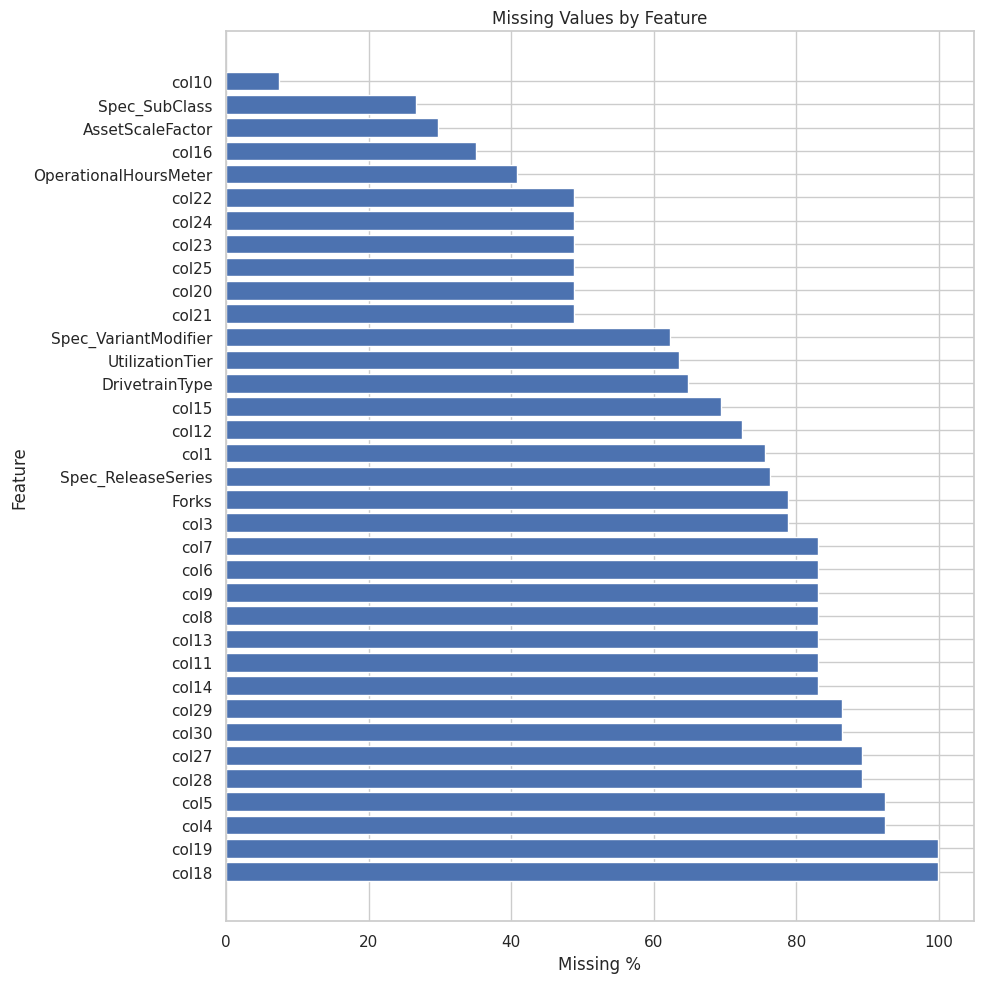

In [13]:
plt.figure(figsize=(10,10))
plt.barh(dic['Feature'],dic['Missing %'])
plt.xlabel("Missing %")
plt.ylabel("Feature")
plt.title("Missing Values by Feature")
plt.tight_layout()
plt.show()

### Observations

From the missing value analysis,the following observations can be made:

- 35 out of 49 features contain missing values.
- `col18` and `col19` contain nearly 100% missing values,making them strong candidates for removal.
- Several other features exhibit more than 80% missing values and require careful treatment during preprocessing.

## 4.2 Unique Value Analysis

The number of unique values in each feature provides insight into feature cardinality. This information is useful for selecting suitable encoding techniques and identifying identifier-like columns.

In [14]:
dic=dict({'Column Name':[],'Number of Unique values':[]})
for col in df:
    dic['Column Name'].append(col)
    dic['Number of Unique values'].append(len(df[col].unique()))
pd.DataFrame(dic)

,Column Name,Number of Unique values
0,TransactionID,138701
1,TargetValue,675
2,AssetID,120111
3,ProductConfigID,3594
4,DataOriginCode,6
5,VendorPartnerID,31
6,ManufactureYear,68
7,OperationalHoursMeter,14644
8,UtilizationTier,4
9,TransactionDate,3676


### Observaions

- Features exhibit varying levels of cardinality.
- High-cardinality categorical features may require encoding techniques such as ordinal or target encoding.
- Features with very few unique values may represent categorical or binary attributes.

## 4.3 Target Variable Overview

The target variable (`TargetValue`) represents the price of heavy equipment. Understanding its statistical characteristics provides an initial indication of its distribution before detailed exploratory analysis.

In [15]:
pd.DataFrame(df['TargetValue'].describe())

,TargetValue
count,138701.000000
mean,41521.874047
std,26361.125948
min,7500.000000
25%,20500.000000
50%,35000.000000
75%,57000.000000
max,142000.000000


### Kwy Observations

- The target variable spans a wide range of prices.
- The mean is higher than the median,suggesting a `positively skewed distribution`.
- A more detailed distribution analysis is presented in the next section of EDA

# 5. Exploratory Data Analysis

Exploratpry Data Analysis (EDA) is performed to understand the underlying characteristics of the dataset through statistical summaries and visualizations. The objecetive is to identify patterns,anomalies,feature distributions,and relationships that can guide data cleaning and feature engineeering.

## 5.1 Target Variable Analysis

Understanding the distribution of the target variable (`TargetValue`) is important for selecting suitable preprocessing techniques and regression models.

In [16]:
print(df['TargetValue'].describe().round(3))
print(f"Skewness: {df['TargetValue'].skew():.3f} thus the data is moderately right-skewed,\nKurtosis: {df['TargetValue'].kurtosis():.3f}: Thus the data has slightly more havier tail than normal distrubtuion")

count    138701.000
mean      41521.874
std       26361.126
min        7500.000
25%       20500.000
50%       35000.000
75%       57000.000
max      142000.000
Name: TargetValue, dtype: float64
Skewness: 0.970 thus the data is moderately right-skewed,
Kurtosis: 0.424: Thus the data has slightly more havier tail than normal distrubtuion


A summary table for Target Value Analysis is:
| Statistic | Value |
|-----------|------:|
| Mean | 41521.874 |
| Median | 35000.000 |
| Standard Deviation | 26361.126 |
| Skewness | 0.970 |
| Kurtosis | 0.424 |

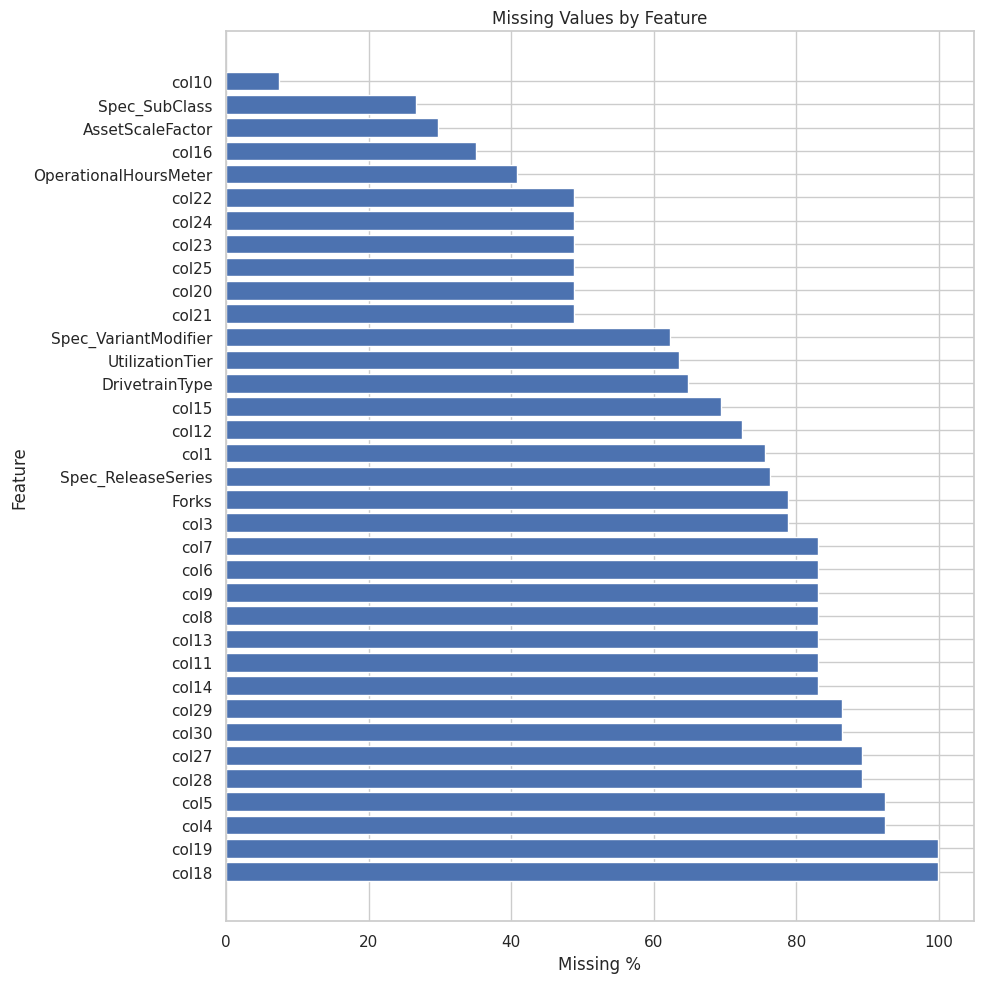

In [17]:
dic=dic={'Feature':[],'Missing Count':[],'Missing %':[]}
null_counts=df.isnull().sum()
for col in df.columns:
    if null_counts[col]!=0:
        dic['Feature'].append(col)
        dic['Missing Count'].append(null_counts[col])
        dic['Missing %'].append(null_counts[col]*100/len(df[col]))
dic=pd.DataFrame(dic).sort_values('Missing %',ascending=False)
dic

plt.figure(figsize=(10,10))
plt.barh(dic['Feature'],dic['Missing %'])
plt.xlabel("Missing %")
plt.ylabel("Feature")
plt.title("Missing Values by Feature")
plt.tight_layout()
plt.show()

### Observations
- It can be verified that the data is positively skewed
- The tail can also be verified to be heavier than a normal distrubution
- The distribution shows that low-moderate monetary value transactions is a lot more common than high monetary value transactions

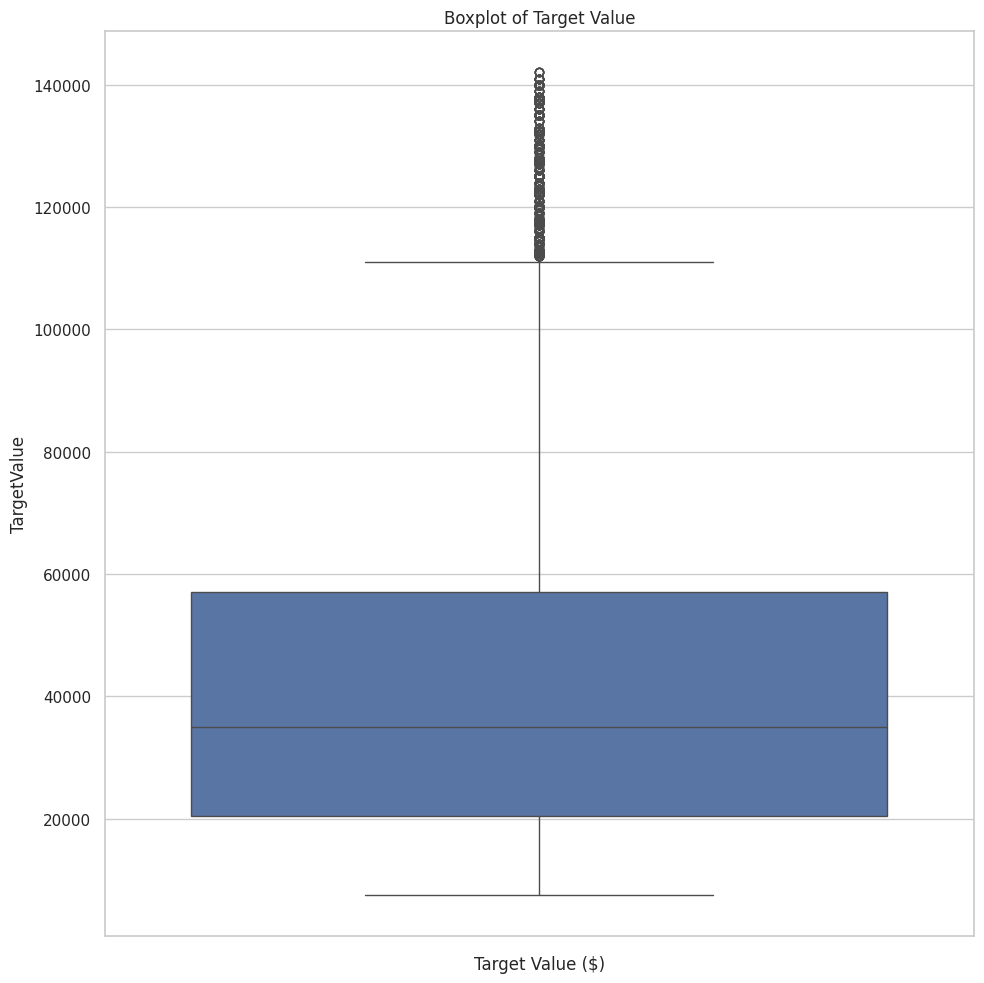

In [18]:
plt.figure(figsize=(10,10))
sns.boxplot(df['TargetValue'])
plt.title("Boxplot of Target Value")
plt.xlabel("Target Value ($)")
plt.tight_layout()
plt.show()

### Observations
- As expected,the box plot as a lot of outliers for high monetary value transactions as those occur far more rarely.
- The median cna be verified to be around 35000 USD
- The model fitting can be harder for models which struggle against outliers like KNN,Linear Regression or other metric-based models.

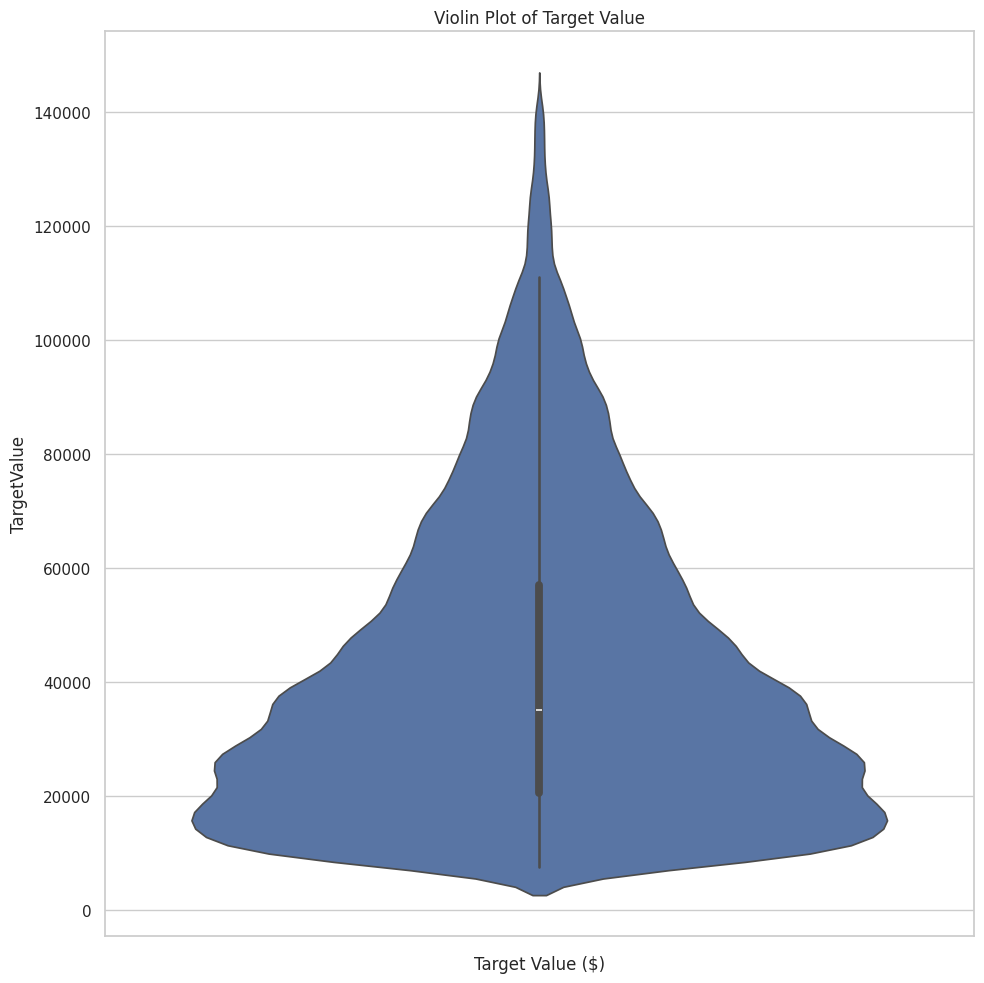

In [19]:
plt.figure(figsize=(10,10))
sns.violinplot(df['TargetValue'])
plt.title("Violin Plot of Target Value")
plt.xlabel("Target Value ($)")
plt.tight_layout()
plt.show()

### Observations
- The data is clearly more clustered around the lower-middle monetary value
- The median can again be verified.

## 5.2 Numerical Feature Analysis

This sction examines the distribution of important numerical variables to identify skewness,outliers,and potentially invalid values that may require preprocessing.

In [20]:
'''
converting TransactionDate into Datetime and checking if there is
any other column with integer entries but stored as object
'''

df['TransactionDate']=pd.to_datetime(df['TransactionDate'])

analysing the features one by one:

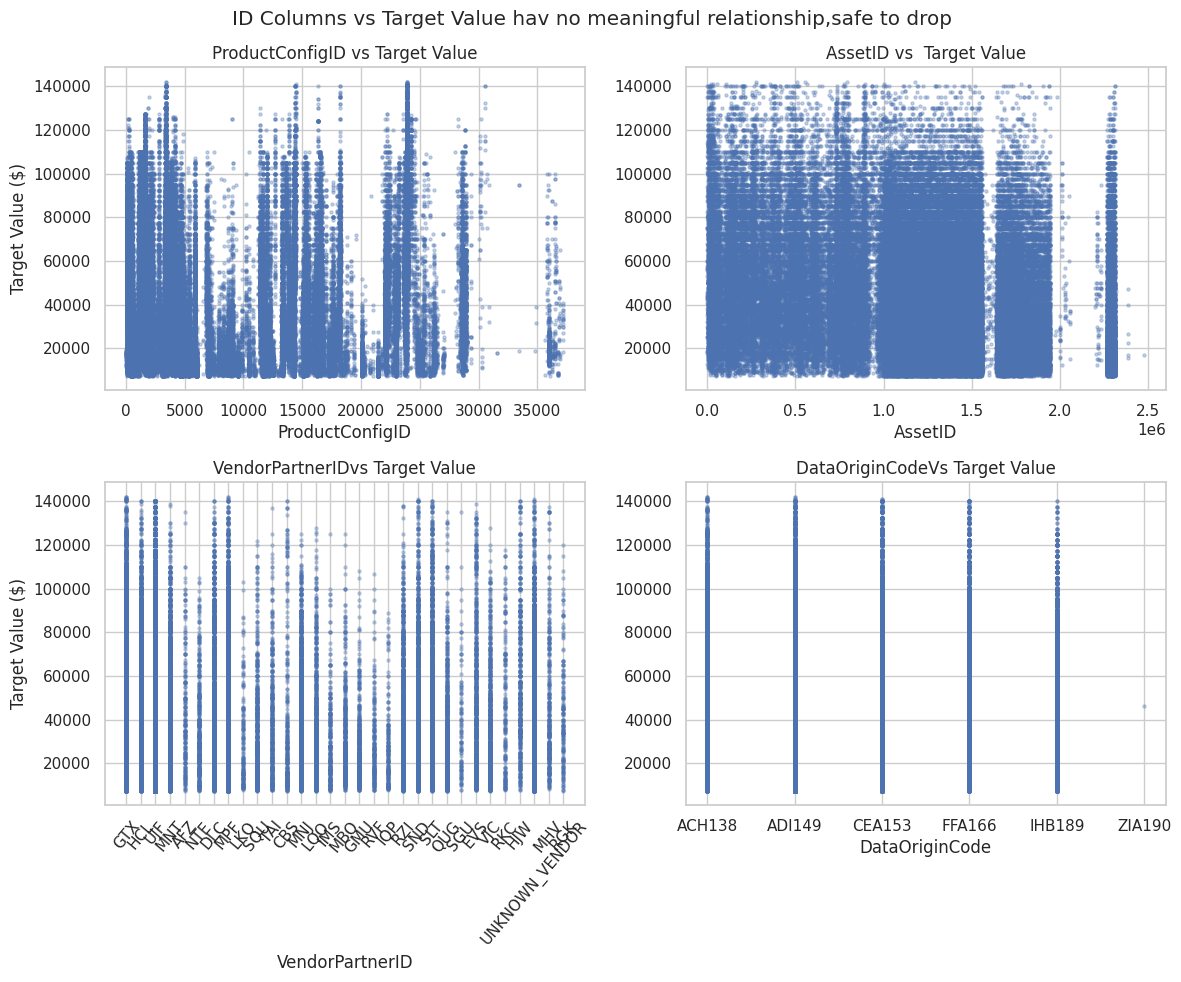

In [21]:
fig,axes=plt.subplots(2,2,figsize=(12,10))

axes[0,0].scatter(df['ProductConfigID'],df['TargetValue'],s=5,alpha=0.3)
axes[0,0].set_title("ProductConfigID vs Target Value")
axes[0,0].set_xlabel("ProductConfigID")
axes[0,0].set_ylabel("Target Value ($)")

axes[0,1].scatter(df['AssetID'],df['TargetValue'],s=5,alpha=0.3)
axes[0,1].set_title("AssetID vs  Target Value")
axes[0,1].set_xlabel("AssetID")

axes[1,0].scatter(df['VendorPartnerID'],df['TargetValue'],s=5,alpha=0.3)
axes[1,0].set_title("VendorPartnerIDvs Target Value")
axes[1,0].set_xlabel("VendorPartnerID")
axes[1,0].tick_params(axis='x',labelrotation=50) 
axes[1,0].set_ylabel("Target Value ($)")

axes[1,1].scatter(df['DataOriginCode'],df['TargetValue'],s=5,alpha=0.3)
axes[1,1].set_title("DataOriginCodeVs Target Value")
axes[1,1].set_xlabel("DataOriginCode")

plt.suptitle("ID Columns vs Target Value hav no meaningful relationship,safe to drop")
plt.tight_layout()
plt.show()

These IDs can thus be dropped

### 5.2.1 ManufactureYear

The manufacturing year provides information about the age of the equipment and is expected to influence its resale value.

In [22]:
df['ManufactureYear'].describe()

count    138701.000000
mean       1891.640853
std         306.992001
min        1001.000000
25%        1990.000000
50%        1998.000000
75%        2004.000000
max        2015.000000
Name: ManufactureYear, dtype: float64

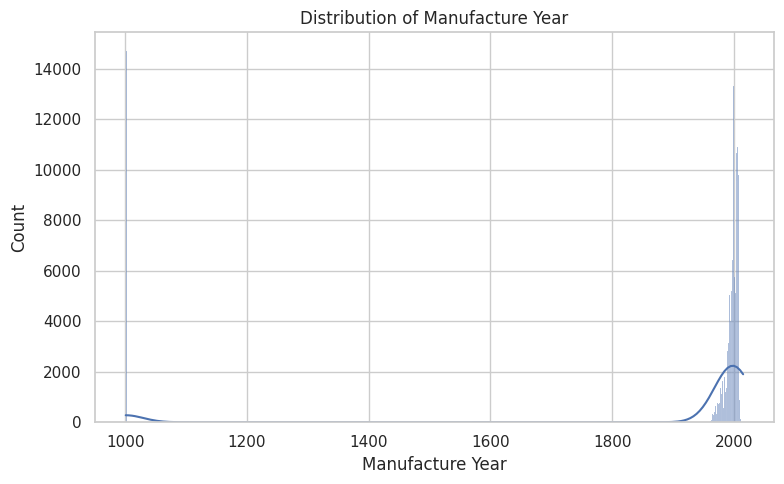

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['ManufactureYear'],kde=True)
plt.title("Distribution of Manufacture Year")
plt.xlabel("Manufacture Year")
plt.tight_layout()
plt.show()

In [24]:
df[df['ManufactureYear']<1800]['ManufactureYear'].unique(),df[df['ManufactureYear']<1800]['ManufactureYear'].count()

(array([1001]), np.int64(14719))

### Observations

- Most machines were manufactured in recent decades.
- A small number of records contain implausible manufacturing years,indicating data quality issues or this 1001 could be a `PLACEHOLDER` for missing entry
- These invalid values will be treated during data cleaning.

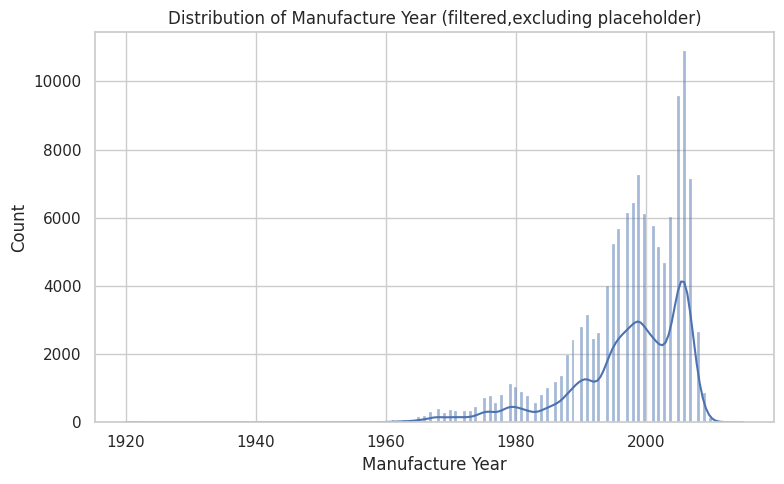

In [25]:
filtered_manufactureyear=df[df['ManufactureYear']>1800]['ManufactureYear']
plt.figure(figsize=(8,5))
sns.histplot(filtered_manufactureyear,kde=True)
plt.title("Distribution of Manufacture Year (filtered,excluding placeholder)")
plt.xlabel("Manufacture Year")
plt.tight_layout()
plt.show()

- Now the histplot looks just fine,with a few outliers from around year 1920s,but they can be legit too. Furhter analyis will suggest its nature
- The data is negatively skewed and indicates the use if machinery has increased rapidy
- The fall of manufacturing in late 2000s can be attributed due to lack of data

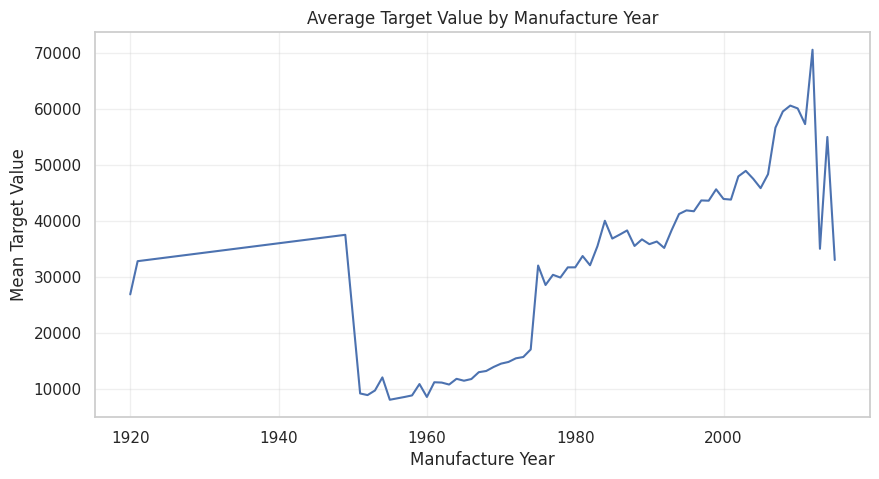

In [26]:
filtered_df=df[df["ManufactureYear"] != 1001]
years_means=filtered_df.groupby("ManufactureYear")["TargetValue"].mean()
plt.figure(figsize=(10,5))
sns.lineplot(x=years_means.index,y=years_means.values)
plt.xlabel("Manufacture Year")
plt.ylabel("Mean Target Value")
plt.title("Average Target Value by Manufacture Year")
plt.grid(True,alpha=0.3)
plt.show()

- This plot suggests  that the value of an arbitrary machinery from 1960s was around 1960s
- The monetary value(on avergae),as expected keeps increasing wrt the machinery getting newer and newer.
- Early manufacturing years contain very few observations,making their average transaction values less reliable
- These 1920s date entry looks like data entry error,we must remove them!

In [27]:
filtered_manufactureyear.corr(filtered_df['TargetValue'])

np.float64(0.2769624044520145)

- The relationship is clearly not very linear and only modest
- Therefore tree based or metric based models might work better than linear models

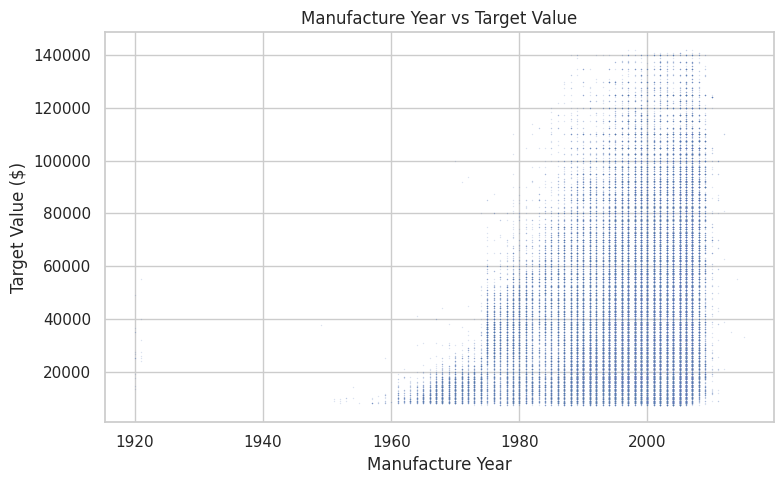

In [28]:
## for sake of completion,we include the scatterplot,though mildly informative only
plt.figure(figsize=(8,5))
sns.scatterplot(x=filtered_manufactureyear,y=filtered_df['TargetValue'],s=1,alpha=0.2)
plt.title("Manufacture Year vs Target Value")
plt.xlabel("Manufacture Year")
plt.ylabel("Target Value ($)")
plt.tight_layout()
plt.show()

Clearly the data is non linear

### 5.2.2 OperationalHoursMeter

Operational hours indicate the usage of the machine and are expected to be an important predictor of target value.

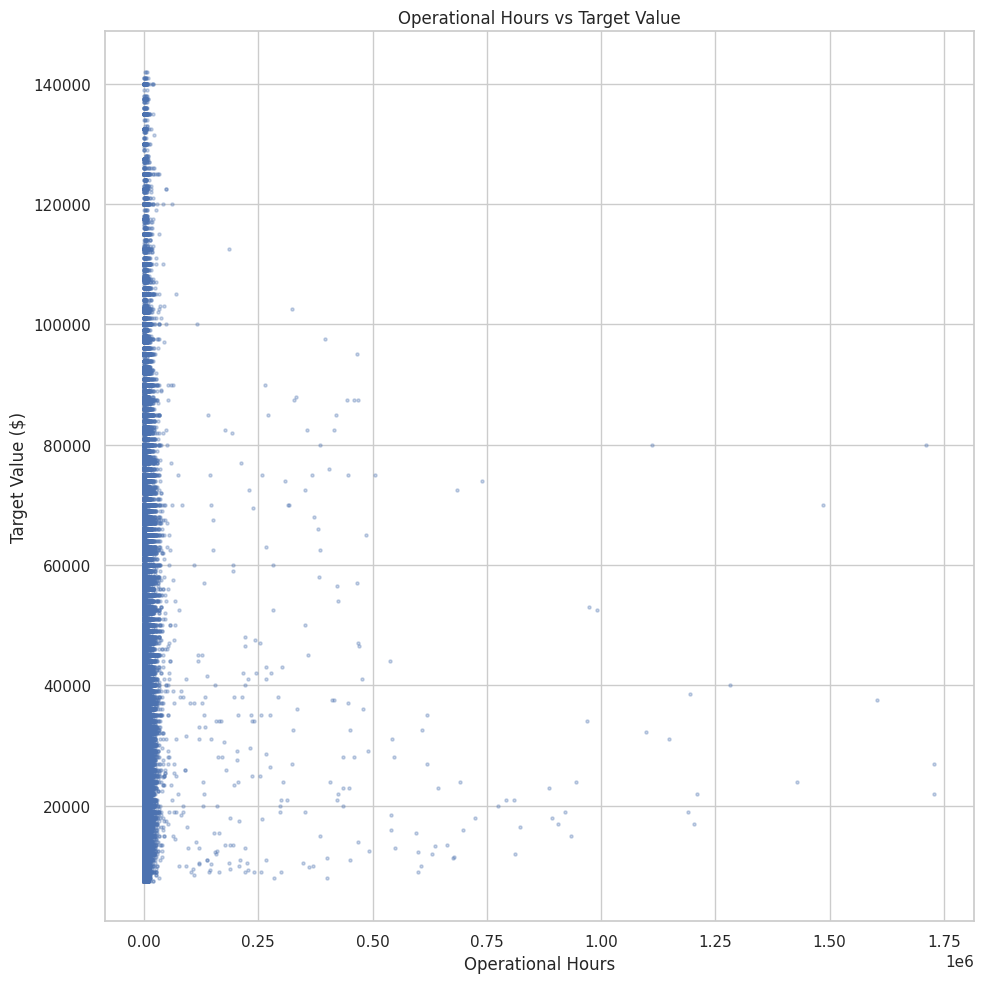

In [29]:
plt.figure(figsize=(10,10))
plt.scatter(df['OperationalHoursMeter'],df['TargetValue'],s=5,alpha=0.3)
plt.title("Operational Hours vs Target Value")
plt.xlabel("Operational Hours")
plt.ylabel("Target Value ($)")
plt.tight_layout()
plt.show()

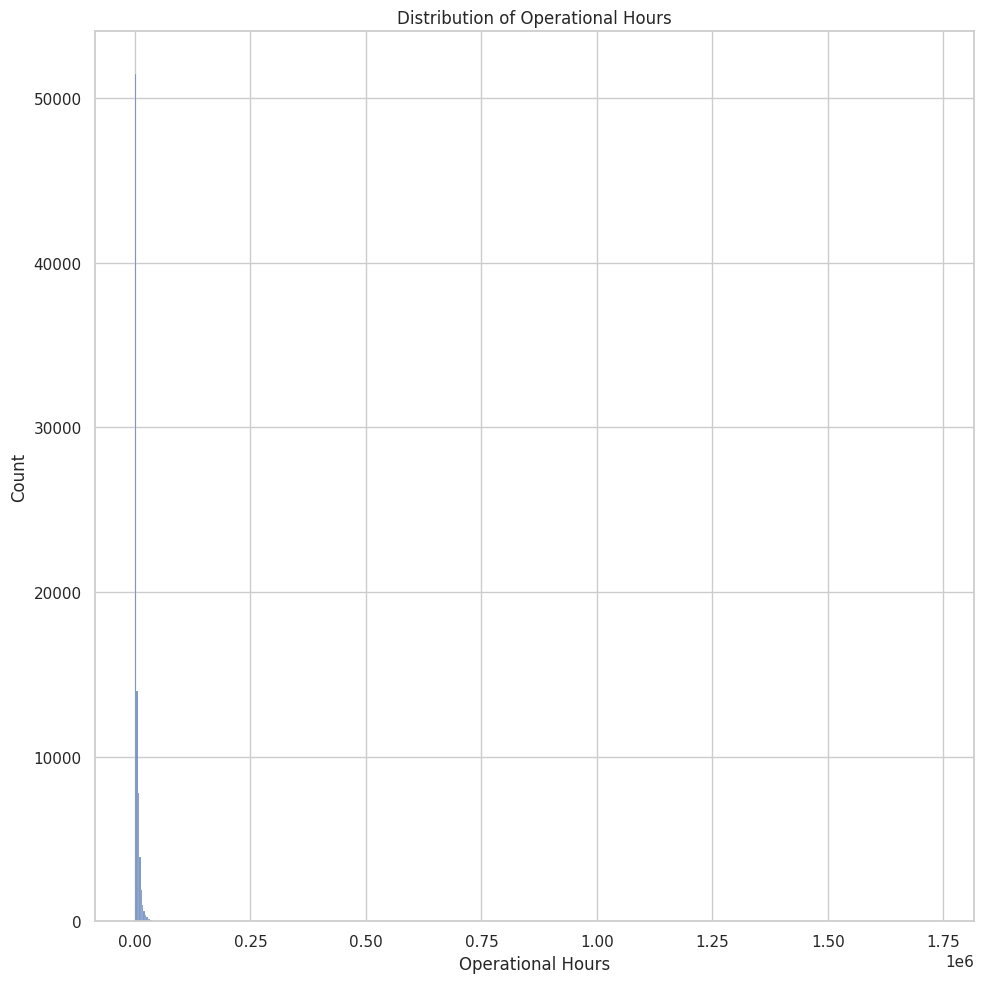

In [30]:
plt.figure(figsize=(10,10))
sns.histplot(df['OperationalHoursMeter'])
plt.title("Distribution of Operational Hours")
plt.xlabel("Operational Hours")
plt.tight_layout()
plt.show()

In [31]:
df['OperationalHoursMeter'].skew()

np.float64(33.28224827296118)

### Observations
- There is definitely some outliers or data entry errors as some datapoints ought to have very high values
The skewness score confirms it too as 33 is enormously skewed.
- C;early no reasonable linear relationship can be found


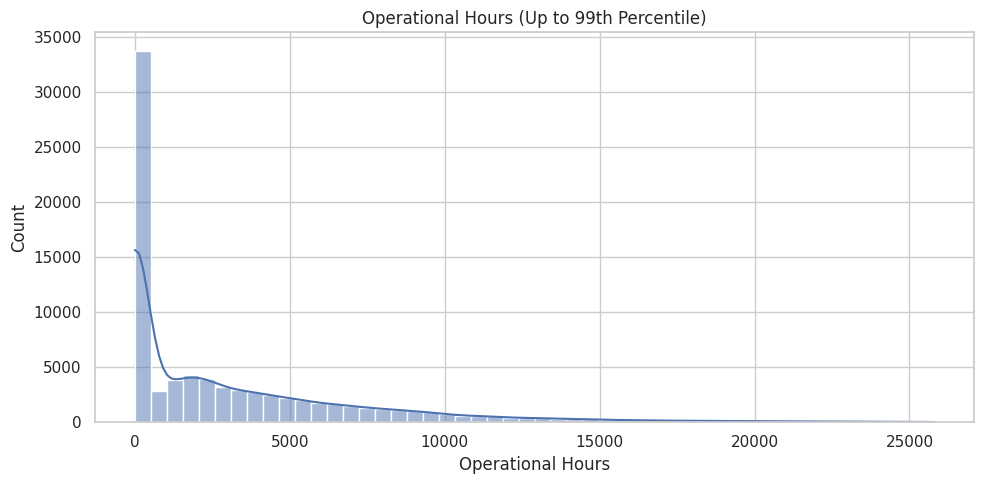

In [32]:
##checking 99th percentile only
percentile_99=df["OperationalHoursMeter"].quantile(0.99)
filtered_hours=df[df["OperationalHoursMeter"] <= percentile_99]
plt.figure(figsize=(10,5))
sns.histplot(filtered_hours["OperationalHoursMeter"],bins=50,kde=True)
plt.title("Operational Hours (Up to 99th Percentile)")
plt.xlabel("Operational Hours")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

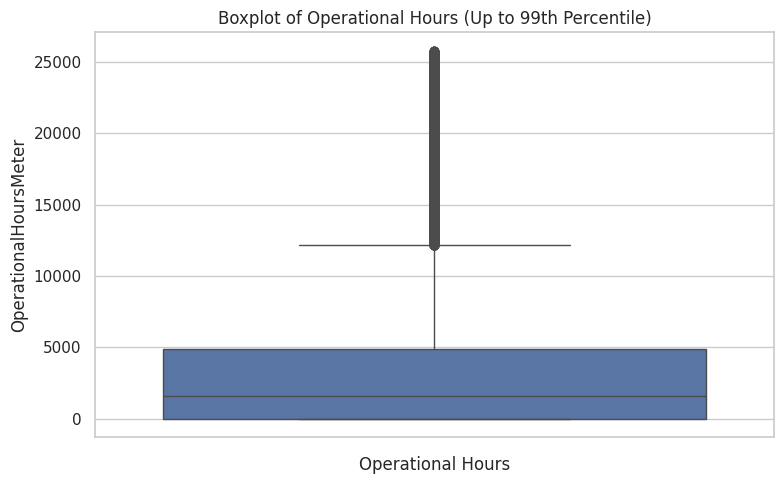

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(filtered_hours["OperationalHoursMeter"])
plt.title("Boxplot of Operational Hours (Up to 99th Percentile)")
plt.xlabel("Operational Hours")
plt.tight_layout()
plt.show()

### OBServation
- The skew shows that Most machines have low lifetime operating hours,whereas only a few machines have very high accumulated operating hours.
- Even after excluding the top 1% of observations for visualization,the distribution remains heavily concentrated at lower operating hours
- This indicates that the skewness is inherent to the feature rather than being caused solely by a few extreme outliers.

## 5.3 Categorical Feature Analysis

Categorical variables describe the specifications and configuration of the equipment. Their frequency distributions help identify dominant categories,inconsistent labels,and high-cardinality features.

In [34]:
for i,col in enumerate(df.columns):
    print(f'The column {df.columns[i]} has unique values: {len(df[col].unique())}')

The column TransactionID has unique values: 138701
The column TargetValue has unique values: 675
The column AssetID has unique values: 120111
The column ProductConfigID has unique values: 3594
The column DataOriginCode has unique values: 6
The column VendorPartnerID has unique values: 31
The column ManufactureYear has unique values: 68
The column OperationalHoursMeter has unique values: 14644
The column UtilizationTier has unique values: 4
The column TransactionDate has unique values: 3676
The column Spec_FullDescriptor has unique values: 3505
The column Spec_BaseClass has unique values: 1249
The column Spec_SubClass has unique values: 148
The column Spec_ReleaseSeries has unique values: 114
The column Spec_VariantModifier has unique values: 133
The column AssetScaleFactor has unique values: 7
The column FunctionalClassification has unique values: 65
The column RegionCode has unique values: 53
The column InventoryGroupCategory has unique values: 6
The column InventoryGroupDescription h

### 5.3.1 Low-Cardinality Features

In [35]:
low_card_features=[]
for col in df.columns:
    if len(df[col].unique())<10:
        low_card_features.append(col)
df[low_card_features].head().T

,0,1,2,3,4
DataOriginCode,ACH138,ACH138,ACH138,ACH138,ACH138
UtilizationTier,Low,Low,High,High,Low
AssetScaleFactor,Medium,NaN,Large / Medium,NaN,Mini
InventoryGroupCategory,WL,BL,TEX,BL,TEX
InventoryGroupDescription,Wheel Loader,Backhoe Loaders,Track Excavators,Backhoe Loaders,Track Excavators
col1,NaN,Four Wheel Drive,NaN,Four Wheel Drive,NaN
CabinType,EROPS w AC,OROPS,EROPS,OROPS,EROPS
Forks,None or Unspecified,None or Unspecified,NaN,None or Unspecified,NaN
col3,None or Unspecified,No,NaN,No,NaN
col4,NaN,Extended,NaN,Standard,NaN


In [36]:
## analysing features which I believe will be important for TargetValue
df['UtilizationTier'].unique()

array(['Low', 'High', 'Medium', nan], dtype=object)

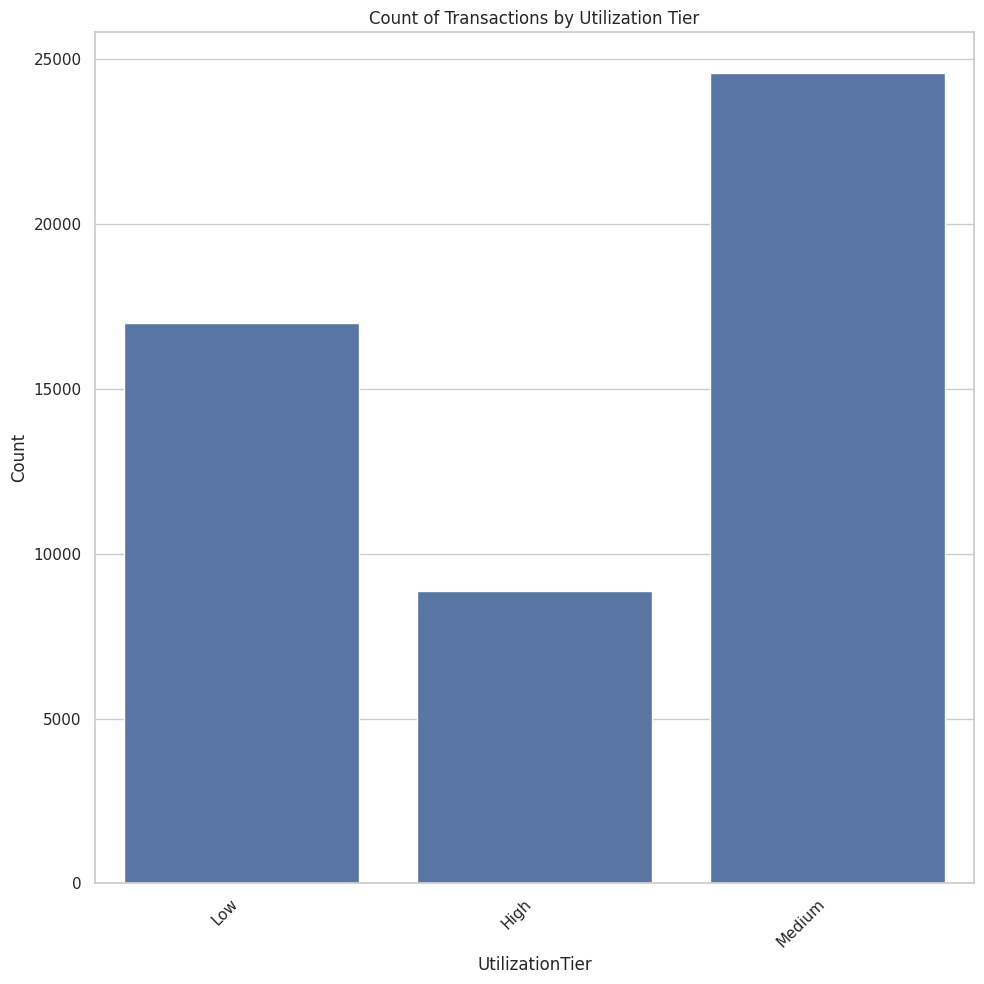

In [37]:
plt.figure(figsize=(10,10))
sns.countplot(x=df['UtilizationTier'])
plt.title("Count of Transactions by Utilization Tier")
plt.ylabel("Count")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

### Observation
- Medium utilization tier is mostly prsent in the dataset.
- The data however isnt overly unbalanced to use techniques like SMOTE(Synthetic Minority Over-sampling Technique)

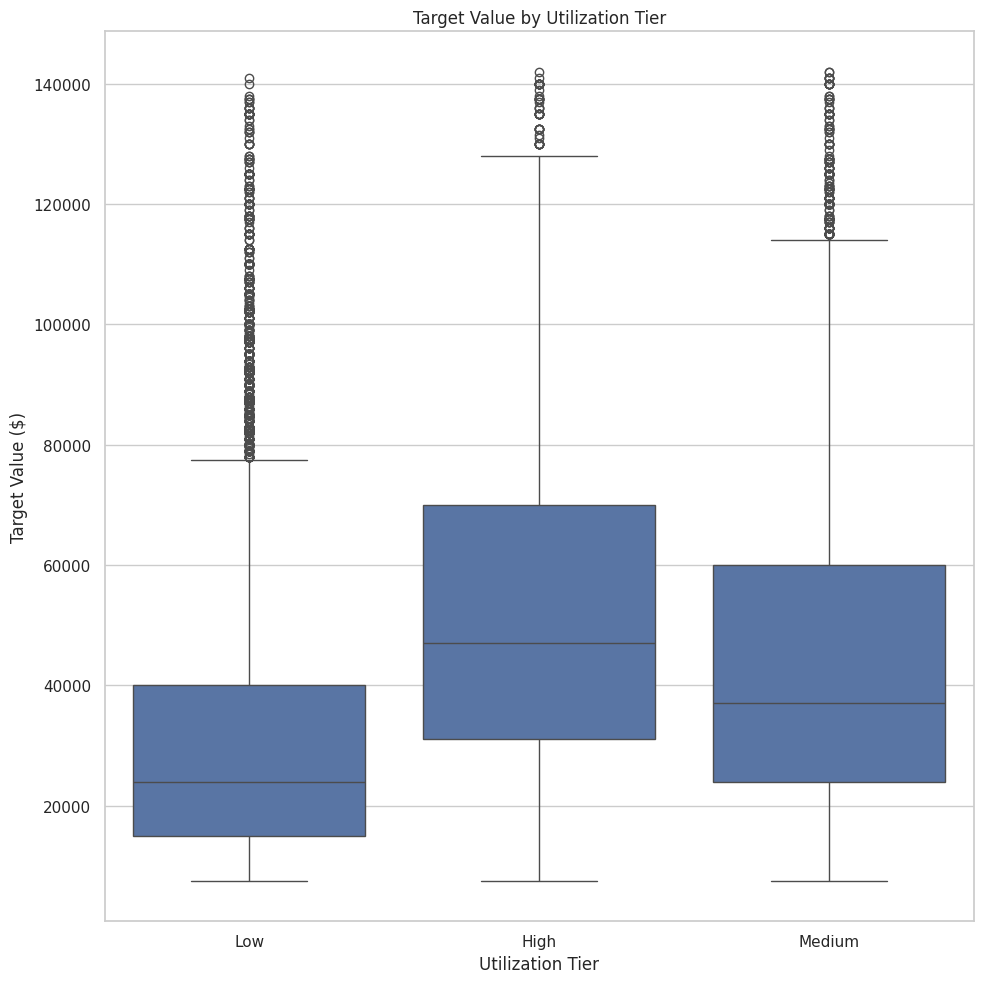

In [38]:
plt.figure(figsize=(10,10))
sns.boxplot(data=df,x="UtilizationTier",y="TargetValue")
plt.title("Target Value by Utilization Tier")
plt.xlabel("Utilization Tier")
plt.ylabel("Target Value ($)")
plt.tight_layout()
plt.show()

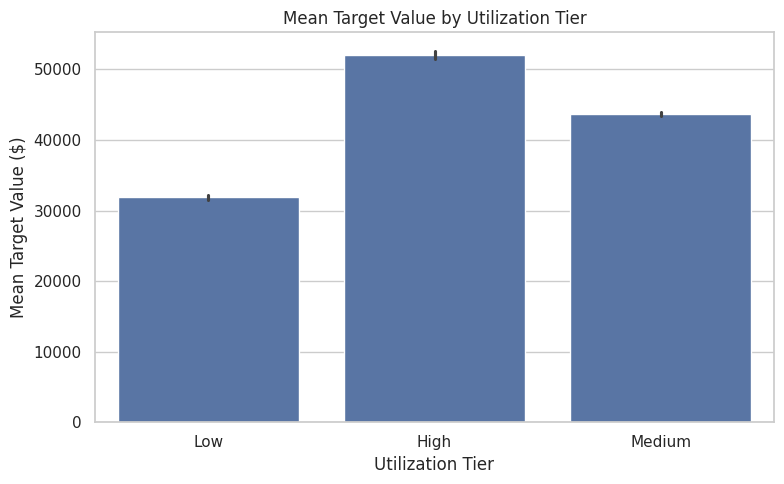

In [39]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x='UtilizationTier',y='TargetValue')
plt.title("Mean Target Value by Utilization Tier")
plt.xlabel("Utilization Tier")
plt.ylabel("Mean Target Value ($)")
plt.tight_layout()
plt.show()

### Observsation
- Intuitively enough,the higher the utilization of asset by the buyer,the higher the value
- The count plot indicates that the High Utilization Tier assets are less in count while medium tier assets are high in count.
- The median of High Utilization is valued highest monetarily
- Considerable overlap exists between the three categories,thus UtilizationTier alone is not enough to explain transaction value.

### 5.3.2 AssetScaleFactor

This feature categorizes machinery according to its physical scale. Larger equipment may command higher prices,making it useful to examine its relationship with the target variable.

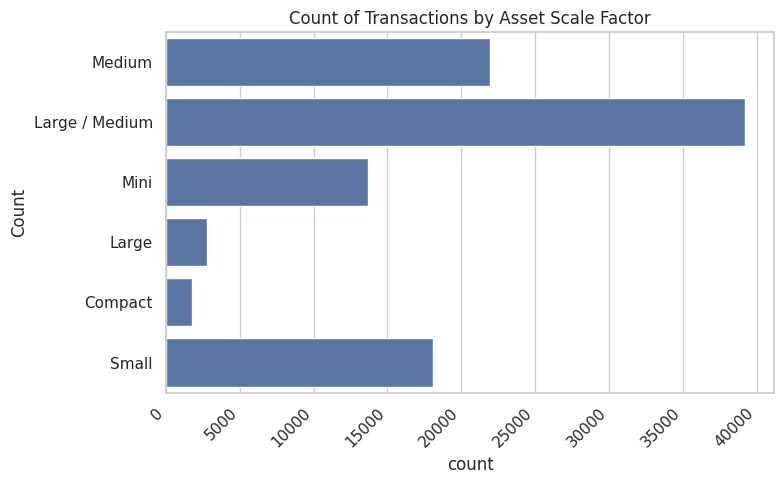

In [40]:
plt.figure(figsize=(8,5))
sns.countplot(df['AssetScaleFactor'])
plt.title("Count of Transactions by Asset Scale Factor")
plt.ylabel("Count")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

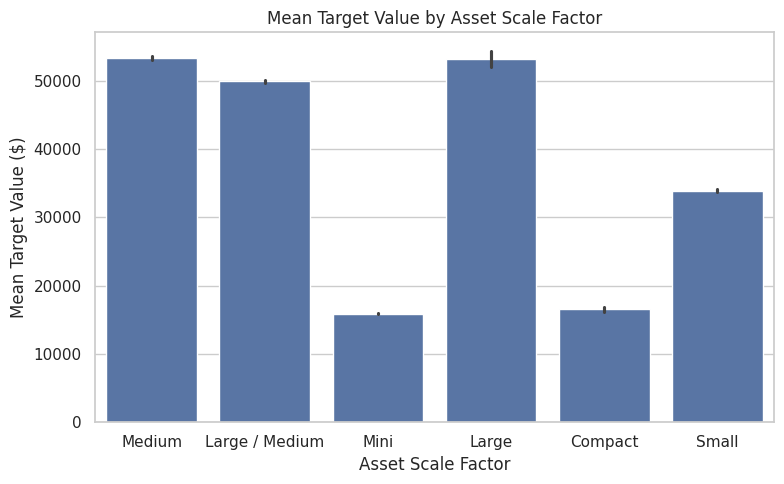

In [41]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="AssetScaleFactor",y="TargetValue")
plt.title("Mean Target Value by Asset Scale Factor")
plt.xlabel("Asset Scale Factor")
plt.ylabel("Mean Target Value ($)")
plt.tight_layout()
plt.show()

### Observation
- This indicates that the Asset Scale Factor has a non-linear R/S as the trend is not very deterministic in the sense that Large has higher value than medium or medium/large
- Bigger machine don't neccassarily mean more transaction monetary value,indicating a non- linear trens

### 5.3.3 InventoryGroupDescription

This feature identifies the broad equipment category. Different machinery types are expected to exhibit different pricing patterns due to variations in functionality,demand,and manufacturing cost.

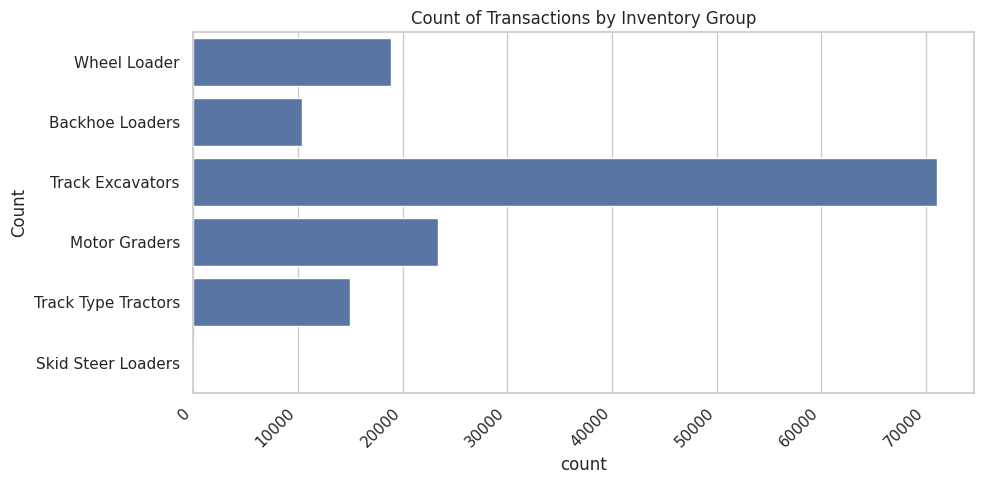

In [42]:
plt.figure(figsize=(10,5))
sns.countplot(df['InventoryGroupDescription'])
plt.title("Count of Transactions by Inventory Group")
plt.ylabel("Count")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

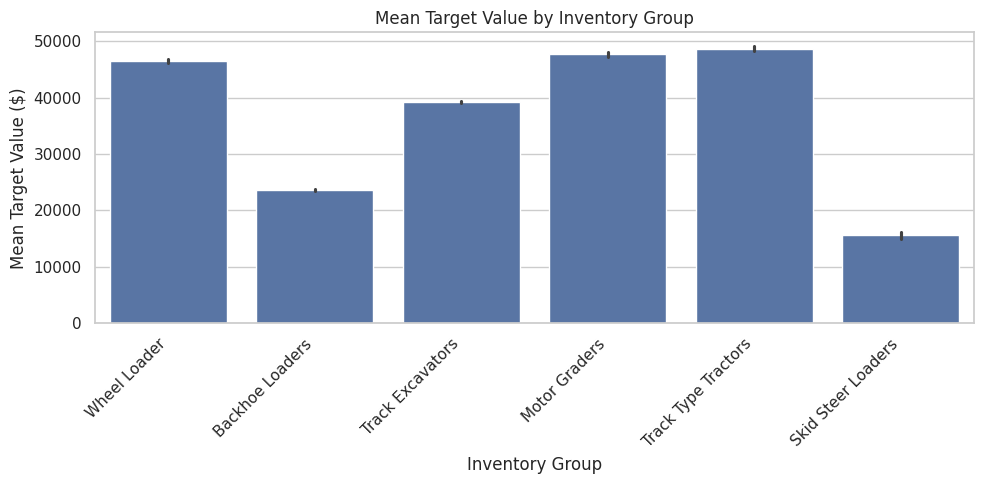

In [43]:
plt.figure(figsize=(10,5))
sns.barplot(data=df,x="InventoryGroupDescription",y="TargetValue")
plt.title("Mean Target Value by Inventory Group")
plt.xlabel("Inventory Group")
plt.ylabel("Mean Target Value ($)")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

In [44]:
df[df['InventoryGroupDescription']=='Skid Steer Loaders']['ManufactureYear'].min() ## indicating its latest manufactured in 2000s

2000

### Observations
- The monetary value of Track Type tractors is clearly the most in market followed by motor graders and wheel loaders
- The skid steer loaders looks ~0,this is because it is a new technology as seen above

### 5.3.4 CabinType

The cabin configuration reflects operator comfort and machine specifications. Premium cabin options may contribute to higher resale values.

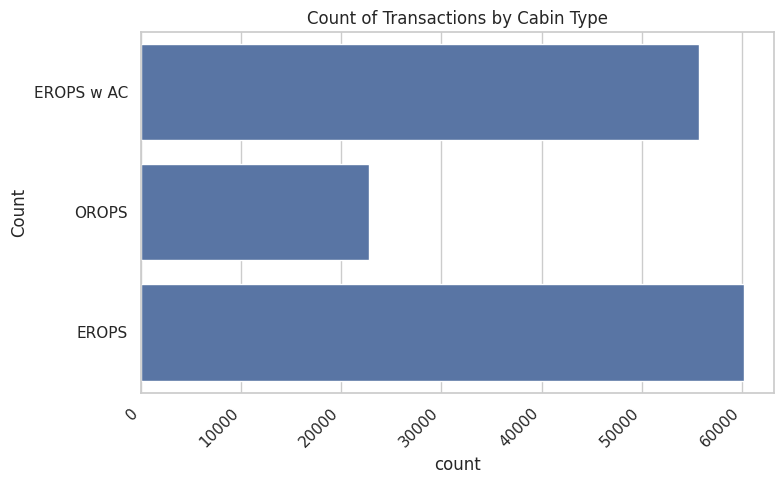

In [45]:
plt.figure(figsize=(8,5))
sns.countplot(df['CabinType'])
plt.title("Count of Transactions by Cabin Type")
plt.ylabel("Count")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

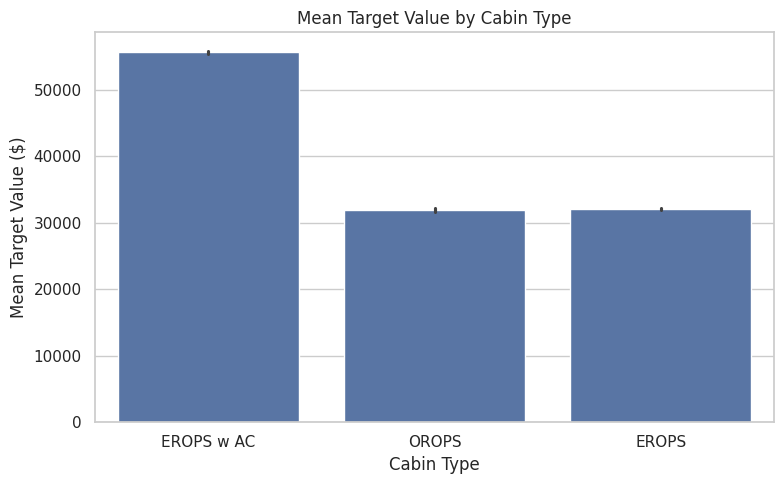

In [46]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="CabinType",y="TargetValue")
plt.title("Mean Target Value by Cabin Type")
plt.xlabel("Cabin Type")
plt.ylabel("Mean Target Value ($)")
plt.tight_layout()
plt.show()

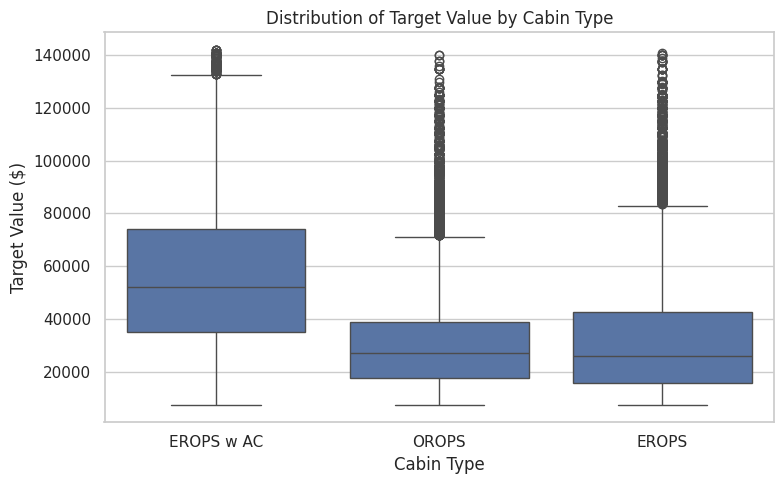

In [47]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="CabinType",y="TargetValue")
plt.title("Distribution of Target Value by Cabin Type")
plt.xlabel("Cabin Type")
plt.ylabel("Target Value ($)")
plt.tight_layout()
plt.show()

### Observations
- EROPS,fully enclosed machinery and EROPS with Air conditioning are approximately same amount in data
- The monetary value as expected is highest for EROPS with ac and similar for OROPS and EROPS,suggesting that the price doesn't increase much with respect to open air or enclosed cabin unless it has AC
- The outliers and median is also very similar for OROPS and EROPS type cabins

### 5.3.5 Analysing Anonymous columns

In [48]:
categorical_cols=[
    "col1","col3","col4","col5","col6","col8",
    "col10","col11","col14","col16","col23",
    "col24","col25","col27","col28","col29","col30"
]

df[categorical_cols].isnull().sum().sort_values()

col10     10381
col16     48745
col23     67683
col24     67683
col25     67685
col1     104915
col3     109448
col6     115296
col14    115296
col8     115296
col11    115296
col29    119829
col30    119829
col27    123742
col28    123742
col4     128320
col5     128320
dtype: int64

In [49]:
categorical_cols=[
    "col1","col3","col4","col5","col6","col8",
    "col10","col11","col14","col16","col23",
    "col24","col25","col27","col28","col29","col30"
]

df[categorical_cols].nunique().sort_values()

col5      2
col4      2
col11     2
col6      2
col30     2
col8      3
col16     3
col3      3
col25     3
col29     3
col23     3
col24     3
col14     3
col1      4
col28     5
col27     9
col10    11
dtype: int64

#### Hydraulic System Classification (`col10`)

This feature represents the hydraulic system classification of the equipment. Hydraulic systems directly influence machine performance and operational capability,making this feature a potentially useful predictor of resale value.

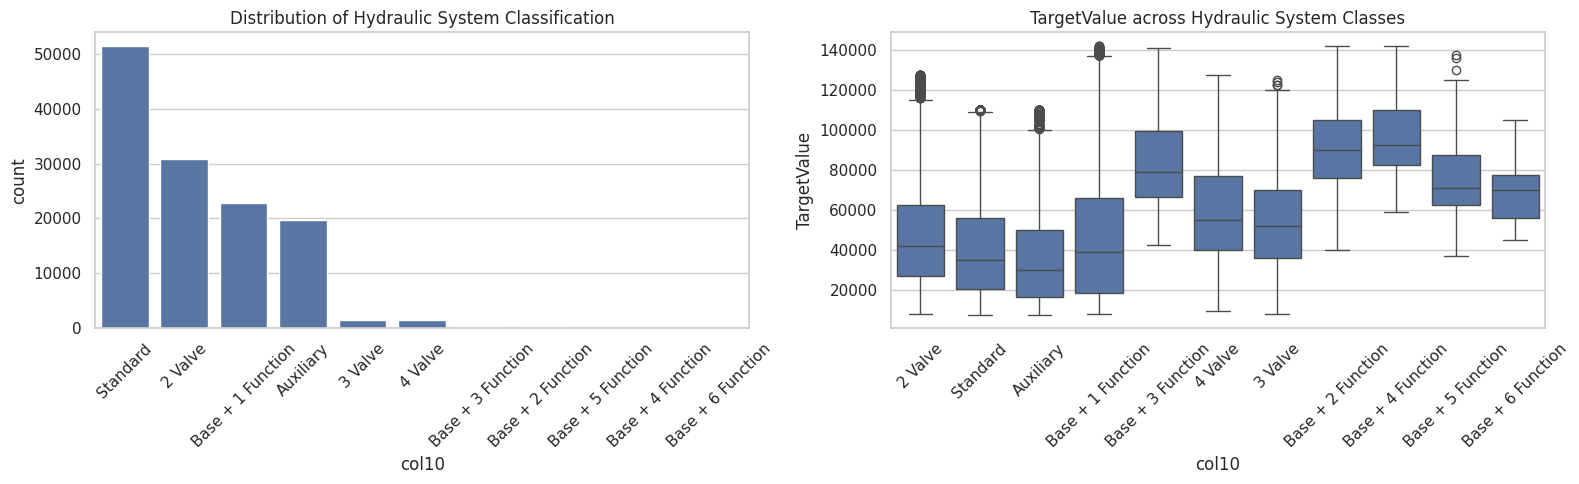

In [50]:
col10_temp=df[df["col10"].notna()].copy()
fig,axes=plt.subplots(1,2,figsize=(16,5))
sns.countplot(data=col10_temp,x="col10",order=col10_temp["col10"].value_counts().index,ax=axes[0])
axes[0].set_title("Distribution of Hydraulic System Classification")
axes[0].tick_params(axis='x',rotation=45)
sns.boxplot(data=col10_temp,x="col10",y="TargetValue",ax=axes[1])
axes[1].set_title("TargetValue across Hydraulic System Classes")
axes[1].tick_params(axis='x',rotation=45)
plt.tight_layout()
plt.show()

### Observatins
- The hydrulic system classes are not uniformly distributed,with some categories occurring much more freqently than others.
- Median resale values vary across hydraulic system classes,suggesting that this feature captures meaningful differences between equipment types.

#### Coupling Mechanism (`col16`)

This feature describes the coupling mechanism used by the equipment. Different coupling mechanisms may correspond to different machine configurations and operational capabilities.

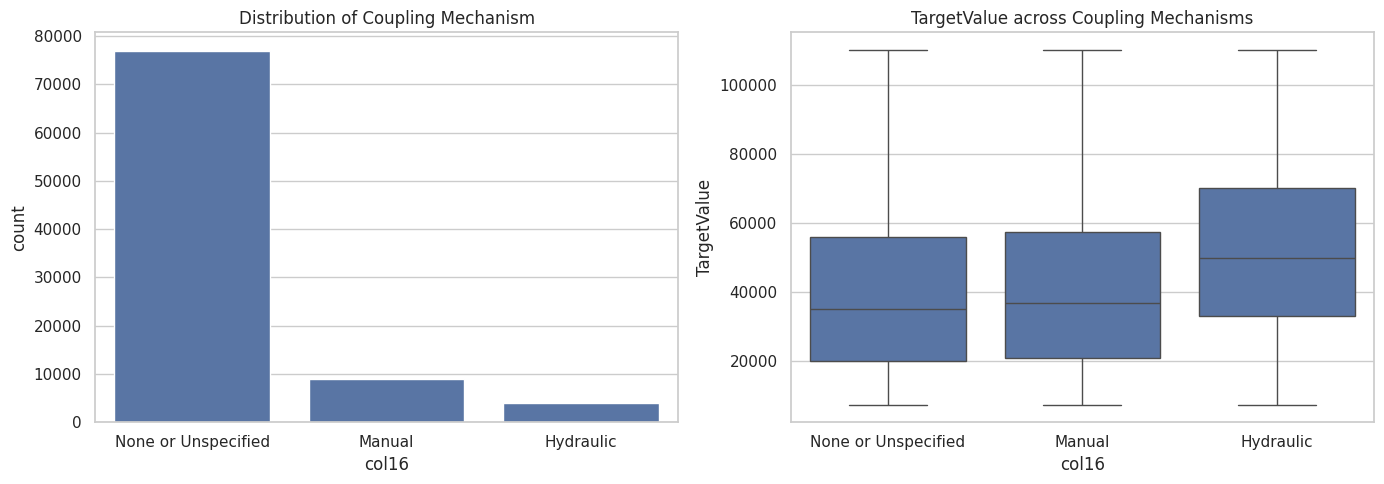

In [51]:
col16_temp=df[df["col16"].notna()].copy()

fig,axes=plt.subplots(1,2,figsize=(14,5))
sns.countplot(data=col16_temp,x="col16",order=col16_temp["col16"].value_counts().index,ax=axes[0])
axes[0].set_title("Distribution of Coupling Mechanism")
sns.boxplot(data=col16_temp,x="col16",y="TargetValue",ax=axes[1])
axes[1].set_title("TargetValue across Coupling Mechanisms")
plt.tight_layout()
plt.show()

### Observations

- None or Unspecified is very high in this feature suggesting null values and thus must be treated

#### Material Holding Interface (`col23`)

This feature represents the material holding interface of the equipment. Different interface configurations may influence the machine's operational capabilities and,consequently,its resale value. The analysis below examines the distribution of the available categories and their relationship with the target variable.

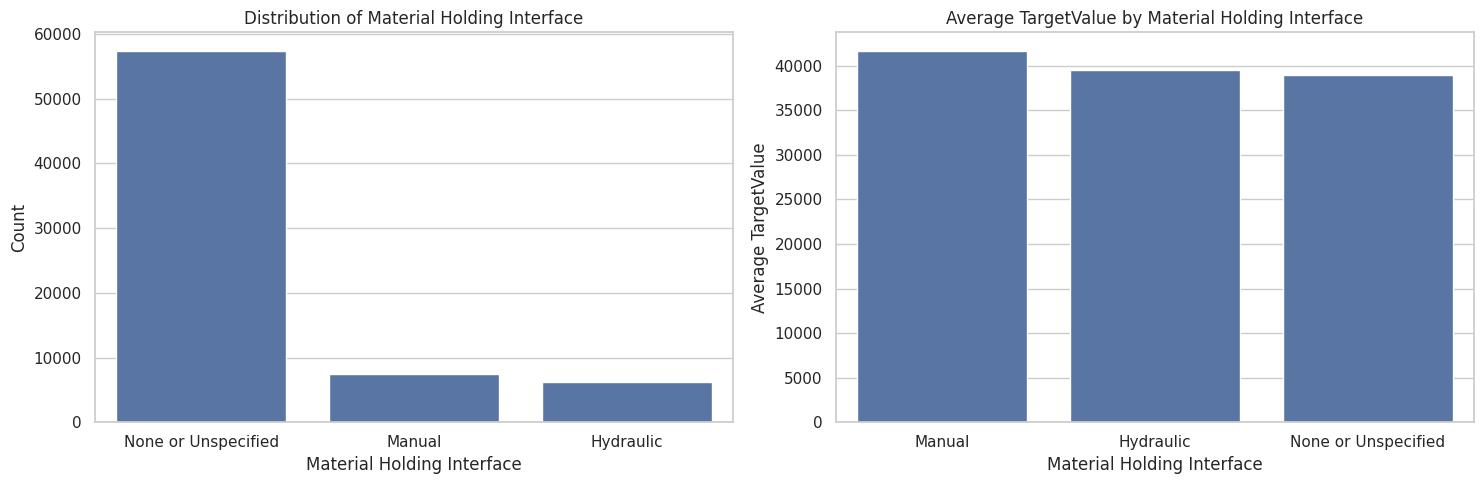

In [52]:
col23_temp=df[df["col23"].notna()].copy()
fig,axes=plt.subplots(1,2,figsize=(15,5))
sns.countplot(data=col23_temp,x="col23",order=col23_temp["col23"].value_counts().index,ax=axes[0])
axes[0].set_title("Distribution of Material Holding Interface")
axes[0].set_xlabel("Material Holding Interface")
axes[0].set_ylabel("Count")
mean_price=(col23_temp.groupby("col23")["TargetValue"].mean().sort_values(ascending=False))
sns.barplot(x=mean_price.index,y=mean_price.values,ax=axes[1])
axes[1].set_title("Average TargetValue by Material Holding Interface")
axes[1].set_xlabel("Material Holding Interface")
axes[1].set_ylabel("Average TargetValue")

plt.tight_layout()
plt.show()

- Clearly here aswell the NaN values are very high in respect of None or Unspecified,we shall treat these columns later

---
The remaining categorical features either contain excessive missing values,extremely high cardinality,or provide limited additional insight through visual analysis. They will be handled appropriately during preprocessing and feature engineering.

#### 5.3.6 High-Cardinality Features

High-cardinality categorical features contain a large number of unique categories. Direct visualization of all categories is impractical; therefore,only the most frequent categories are examined.

In [53]:
high_card_features=[]
for col in df.columns:
    if (len(df[col].unique())>=10) and df[col].dtype=='object':
        high_card_features.append(col)
df[high_card_features].T

,0,1,2,3,4,5,6,7,8,9,...,138691,138692,138693,138694,138695,138696,138697,138698,138699,138700
VendorPartnerID,GTX,GTX,GTX,GTX,GTX,GTX,GTX,GTX,GTX,GTX,...,UJF,MPF,MPF,MPF,UJF,MPF,MPF,MPF,MPF,MPF
Spec_FullDescriptor,950FII,310G,790ELC,416D,430HAG,988B,310G,PC200LC6,420D,214E,...,35NX2,30NX,30NX,30NX,30NX,30NX,30NX2,30NX,30NX,30NX2
Spec_BaseClass,950,310,790,416,430,988,310,PC200,420,214,...,35,30,30,30,30,30,30,30,30,30
Spec_SubClass,F,G,E,D,HAG,B,G,NaN,D,E,...,NX,NX,NX,NX,NX,NX,NX,NX,NX,NX
Spec_ReleaseSeries,II,NaN,NaN,NaN,NaN,NaN,NaN,LC,NaN,NaN,...,2,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,2
Spec_VariantModifier,NaN,NaN,LC,NaN,NaN,NaN,NaN,6,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FunctionalClassification,Wheel Loader - 150.0 to 175.0 Horsepower,Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...,"Hydraulic Excavator, Track - 21.0 to 24.0 Metr...",Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...,"Hydraulic Excavator, Track - 3.0 to 4.0 Metric...",Wheel Loader - 350.0 to 500.0 Horsepower,Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...,"Hydraulic Excavator, Track - 19.0 to 21.0 Metr...",Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...,Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...,...,"Hydraulic Excavator, Track - 3.0 to 4.0 Metric...","Hydraulic Excavator, Track - 2.0 to 3.0 Metric...","Hydraulic Excavator, Track - 2.0 to 3.0 Metric...","Hydraulic Excavator, Track - 2.0 to 3.0 Metric...","Hydraulic Excavator, Track - 2.0 to 3.0 Metric...","Hydraulic Excavator, Track - 2.0 to 3.0 Metric...","Hydraulic Excavator, Track - 3.0 to 4.0 Metric...","Hydraulic Excavator, Track - 2.0 to 3.0 Metric...","Hydraulic Excavator, Track - 2.0 to 3.0 Metric...","Hydraulic Excavator, Track - 3.0 to 4.0 Metric..."
RegionCode,North Carolina,Arizona,Florida,Illinois,Texas,Florida,Oregon,Ohio,Texas,North Carolina,...,Maryland,Florida,Florida,Florida,Florida,Texas,Florida,Florida,Texas,Florida
col10,2 Valve,NaN,Standard,NaN,Auxiliary,2 Valve,NaN,Auxiliary,NaN,NaN,...,Auxiliary,Auxiliary,Standard,Standard,Standard,Standard,Auxiliary,Auxiliary,Auxiliary,Auxiliary
col15,23.5,NaN,NaN,NaN,NaN,None or Unspecified,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


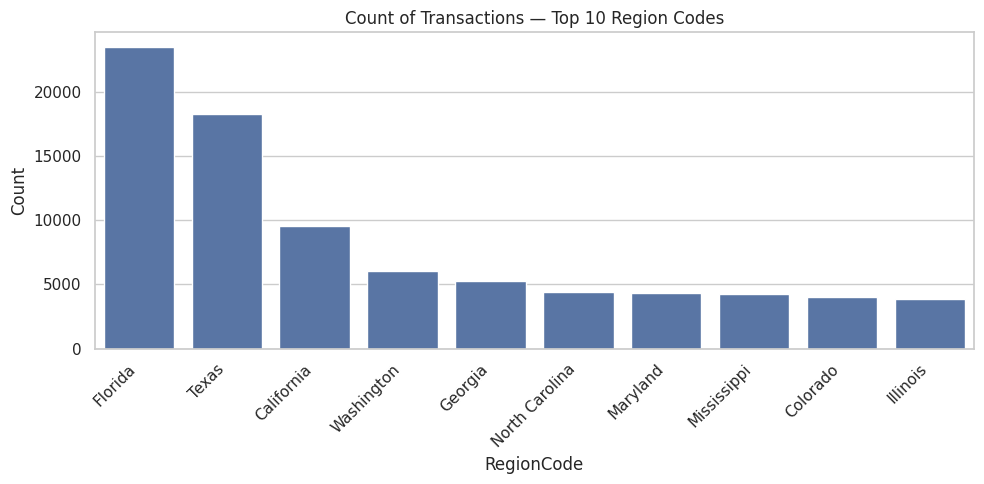

In [54]:
plt.figure(figsize=(10,5))
top10=df["RegionCode"].value_counts().head(10).index
sns.countplot(data=df[df["RegionCode"].isin(top10)],x="RegionCode",order=top10)
plt.title("Count of Transactions — Top 10 Region Codes")
plt.ylabel("Count")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

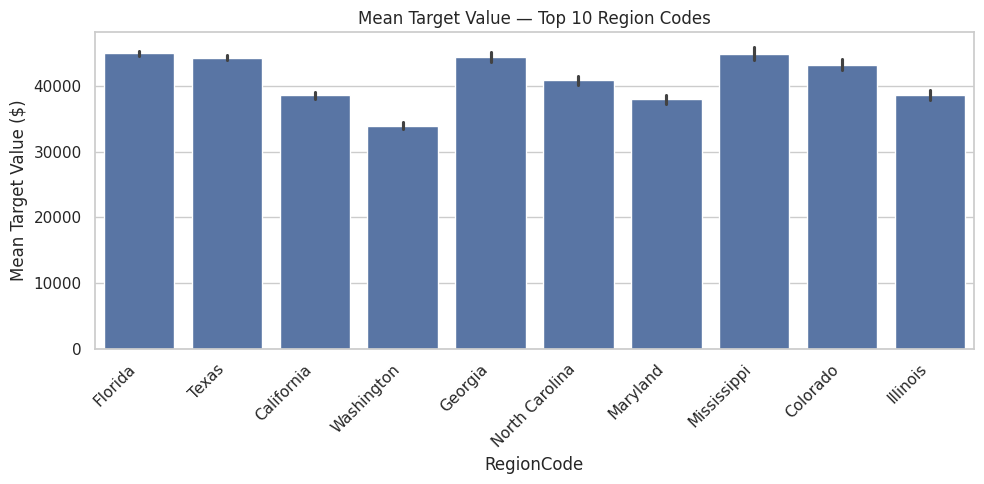

In [55]:
plt.figure(figsize=(10,5))
sns.barplot(data=df[df["RegionCode"].isin(top10)],x="RegionCode",y="TargetValue",order=top10)
plt.title("Mean Target Value — Top 10 Region Codes")
plt.ylabel("Mean Target Value ($)")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

The region of purchase has little to no impact on the monetary value of the machinery,this feature can thus be dropped in data engineering or the PCA can attribute it to be very little variance capture

## 5.4 Date & Time Analysis

In [56]:
print("Train:", df["TransactionDate"].min(), "to", df["TransactionDate"].max())
print("Test:", test["TransactionDate"].min(), "to", test["TransactionDate"].max())

Train: 1990-01-31 00:00:00 to 2013-04-28 00:00:00
Test: 1990-01-31 to 2013-04-28


### Observation:
- This suggests to us that the date ranges similar in both train and test data.
- THIS IMPLIES WE CAN SPLIT TRAIN AND VAL SET WITHOUT ANY WORRIES(IF TEST DATA WAS OF UPCOMING YEARS, WE MUST HAVE SPLITTED BASED OF YEARS)

In [57]:
## creating features we require right now
df["TransactionYear"]=df["TransactionDate"].dt.year
df["TransactionMonth"]=df["TransactionDate"].dt.month

##doing same for testing data without any leakage
test['TransactionDate']=pd.to_datetime(test['TransactionDate'])
test["TransactionYear"]=test["TransactionDate"].dt.year
test["TransactionMonth"]=test["TransactionDate"].dt.month

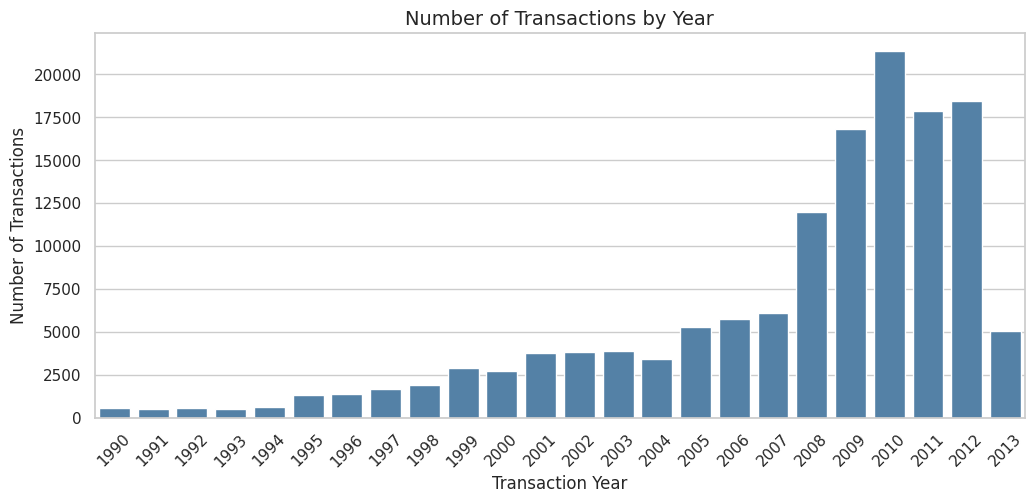

In [58]:
plt.figure(figsize=(12,5))
sns.countplot(data=df,x='TransactionYear',order=sorted(df['TransactionYear'].unique()),color='steelblue')
plt.title('Number of Transactions by Year',fontsize=14)
plt.xlabel('Transaction Year')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

- This suggests the data has most of the transactions from 2010 period
- This implies the number of trsnactions keep increasing in the data with each year

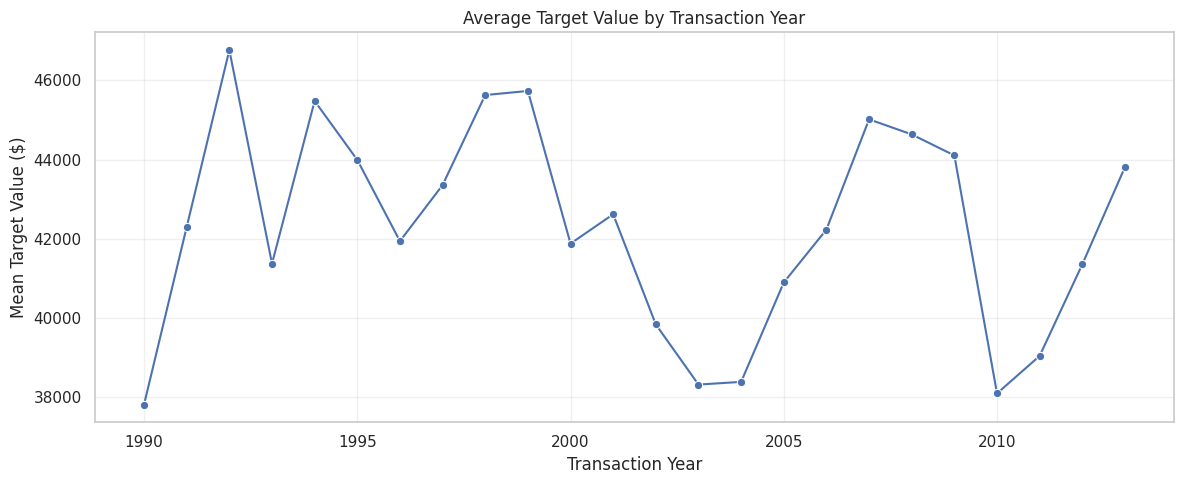

In [59]:
year_target=(df.groupby("TransactionYear")["TargetValue"].mean())
plt.figure(figsize=(12,5))
sns.lineplot(x=year_target.index,y=year_target.values,marker="o")
plt.title("Average Target Value by Transaction Year")
plt.xlabel("Transaction Year")
plt.ylabel("Mean Target Value ($)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- The data indicates that there is a cyclic trend to the Value of transactions,it could be due to various economical trends like recession etc.

- Major Troughs can be observed in year ~2003 and ~2010. Which is counter-intuitive as manufacturing newer years indicated an upward trend in the price. Yet the macroeconomics factors must be commanding the price and indicating an average lower price for the machine

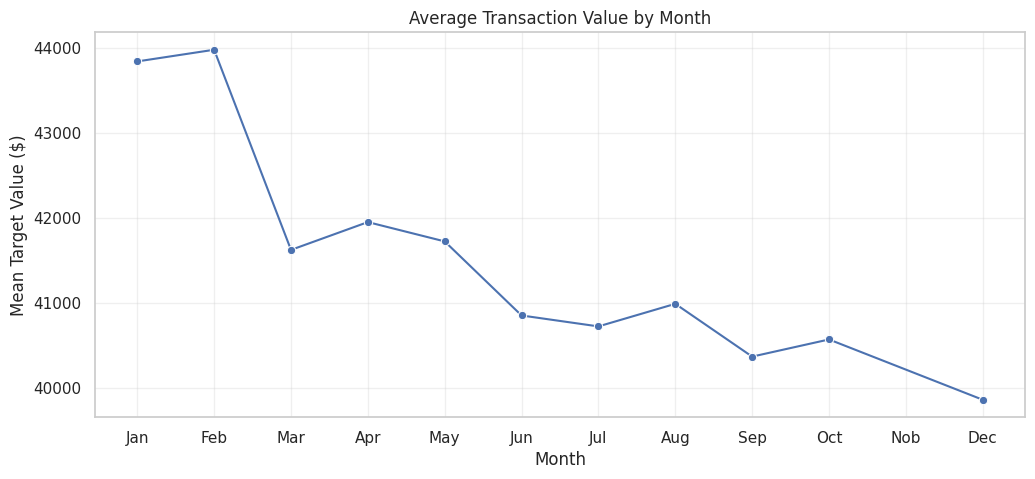

In [60]:
month_names={1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
df["MonthName"]=df["TransactionMonth"].map(month_names)

month_order=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nob','Dec']
monthly_means=df.groupby("MonthName")["TargetValue"].mean().reindex(month_order)
plt.figure(figsize=(12,5))
sns.lineplot(x=monthly_means.index,y=monthly_means.values,marker="o")
plt.title("Average Transaction Value by Month")
plt.xlabel("Month")
plt.ylabel("Mean Target Value ($)")
plt.grid(True,alpha=0.3)
plt.show()


In [61]:
df.drop('MonthName',axis=1,inplace=True)

- The average transaction value is more or less the same across the months
- January and February observe the highest transaction value with December observing the least

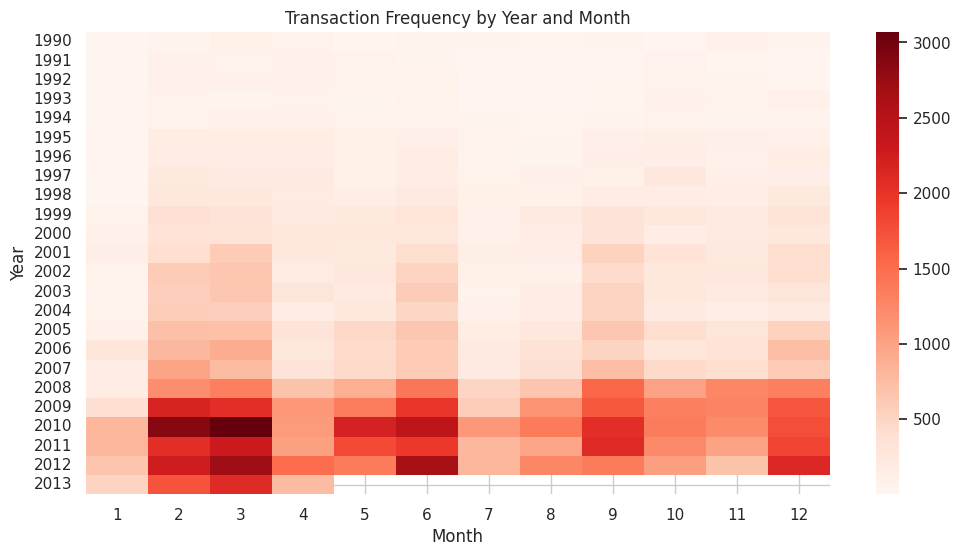

In [62]:
heatmap_data=df.groupby(['TransactionYear','TransactionMonth']).size().unstack()
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data,cmap='Reds')
plt.title('Transaction Frequency by Year and Month')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

## 5.5 Feature Relationship

In [63]:
print(df["Spec_FullDescriptor"].dropna().sample(10, random_state=1).tolist())

['345BIIL', '490E', 'PC75UU-2', 'ROBEX210LC', '966B', '322G', '544H', 'TB016', '12G', '312C']


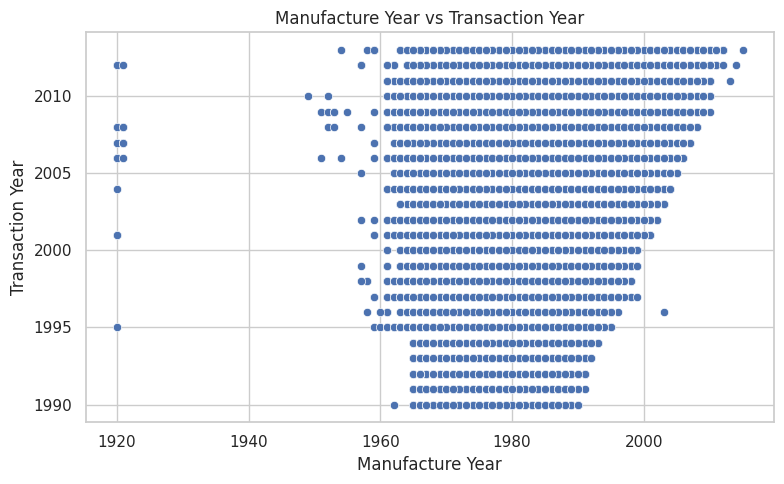

In [64]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=filtered_manufactureyear,y=df[df['ManufactureYear']!=1001]['TransactionYear'])
plt.title("Manufacture Year vs Transaction Year")
plt.xlabel("Manufacture Year")
plt.ylabel("Transaction Year")
plt.tight_layout()
plt.show()

- The data obviously forms a triangular trend as ManufactureYear >= TransactionYear,the abnormalities shall be treated later.
- We can make a new column like AssetAge to merge the information and reduce features

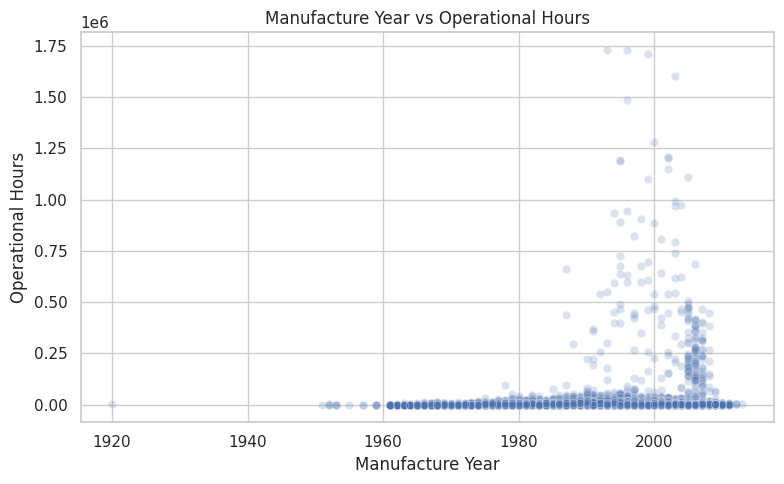

In [65]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=filtered_manufactureyear,y=filtered_df['OperationalHoursMeter'],alpha=0.2)
plt.title("Manufacture Year vs Operational Hours")
plt.xlabel("Manufacture Year")
plt.ylabel("Operational Hours")
plt.tight_layout()
plt.show()

this suggests that there are many entries at 0 mark forOperationalHoursMeter. Indicating a potential issue in the data entry.
- the 1920 entries are for sure an issue as most of the EDA showed that it has extreme values. We shall handle it too

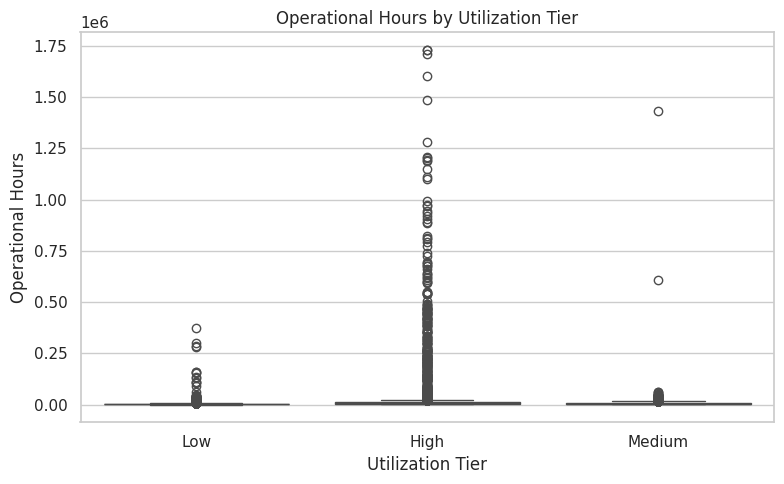

In [66]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['UtilizationTier'],y=df['OperationalHoursMeter'])
plt.title("Operational Hours by Utilization Tier")
plt.xlabel("Utilization Tier")
plt.ylabel("Operational Hours")
plt.tight_layout()
plt.show()

- This properly explains why the OperationalHoursMeter was skewed ~33.
- But most of the OperationalHoursMeter is attributed to the High Utilization Tier
- This should be treated in Data Cleaning,log transformation can be used to treat this feature properly

In [67]:
# # re-attach TransactionYear to filtered_df so it can join the correlation matrix below
filtered_df['TransactionYear']=df[df['ManufactureYear']!=1001]['TransactionYear']

/tmp/ipykernel_23/2373261841.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['TransactionYear']=df[df['ManufactureYear']!=1001]['TransactionYear']


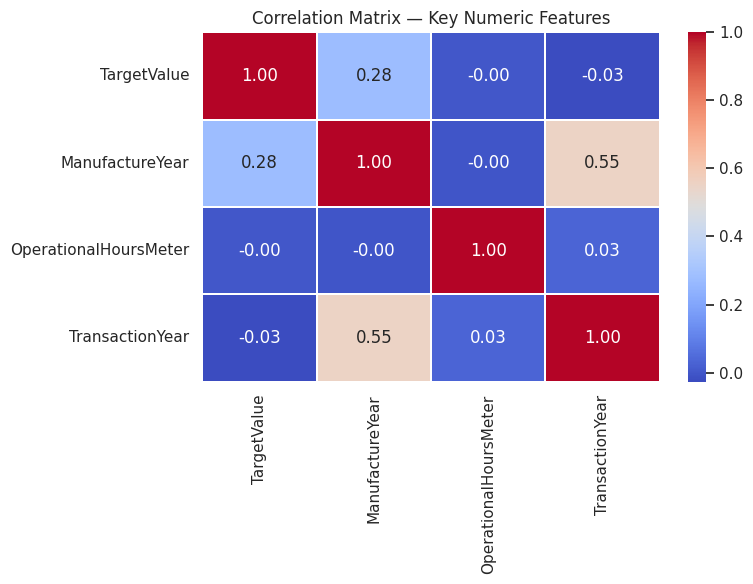

In [68]:
##initial correlation map before feature engineering and data type changes
num_features=filtered_df[['TargetValue','ManufactureYear','OperationalHoursMeter','TransactionYear']]
corr=num_features.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f',linewidth=0.2)
plt.title("Correlation Matrix — Key Numeric Features")
plt.tight_layout()
plt.show()

- The presence of a lot of 0 values and outliers in OperationalHoursMeter is evident as the correlation is ~0 with every feature. This feature must be treated.
- The correlation between manufacture year and Transaction year is obvious
- There is a clear non-linear trend in the data and thus non-linear models must be used

# 6. Data Cleaning

Based on the insights obtained from the exploratory data analysis,the dataset is cleaned to improve data quality and ensure consistency before feature engineering and model development. This includes handling missing values,correcting invalid entries,and preparing date-related features.

## 6.1 Handling Missing Values

The missing value analysis revealed that several features contained a substantial number of missing observations. Features with extremely high missingness contribute limited information and may negatively impact model performance. Therefore,an appropriate cleaning strategy is adopted before further processing.

In [69]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
TransactionID,138701.0,2186275.950556,1139309.0,1465754.0,1751884.0,2372139.0,6333410.0,1128496.619347
TargetValue,138701.0,41521.874047,7500.0,20500.0,35000.0,57000.0,142000.0,26361.125948
AssetID,138701.0,1204814.320423,8.0,1007930.0,1246956.0,1495817.0,2478476.0,528737.593449
ProductConfigID,138701.0,7286.421922,39.0,1693.0,3852.0,11873.0,37209.0,7542.421537
ManufactureYear,138701.0,1891.640853,1001.0,1990.0,1998.0,2004.0,2015.0,306.992001
OperationalHoursMeter,82058.0,4553.718943,0.0,0.0,1620.0,5001.0,1729600.0,27922.04485
TransactionDate,138701,2007-12-20 17:36:50.415209728,1990-01-31 00:00:00,2005-11-18 00:00:00,2009-08-20 00:00:00,2011-05-12 00:00:00,2013-04-28 00:00:00,NaN
TransactionYear,138701.0,2007.489932,1990.0,2005.0,2009.0,2011.0,2013.0,4.792396
TransactionMonth,138701.0,6.257597,1.0,3.0,6.0,9.0,12.0,3.447017


In [70]:
test.describe().T

,count,mean,min,25%,50%,75%,max,std
TransactionID,15000.0,2199650.028867,1139307.0,1468021.0,1750341.0,2372531.75,6333397.0,1145245.315719
AssetID,15000.0,1199748.225867,174.0,1006622.0,1243943.0,1488693.0,2484757.0,527771.115861
ProductConfigID,15000.0,7174.697867,39.0,1841.0,3834.0,11645.0,37208.0,7434.103786
ManufactureYear,15000.0,1892.378,1001.0,1990.0,1998.0,2004.0,2015.0,305.978851
OperationalHoursMeter,8809.0,4460.034283,0.0,0.0,1534.0,5023.0,932000.0,22541.301953
TransactionDate,15000,2007-12-25 08:29:51.360000,1990-01-31 00:00:00,2005-12-02 00:00:00,2009-08-07 00:00:00,2011-05-14 00:00:00,2013-04-28 00:00:00,NaN
TransactionYear,15000.0,2007.505667,1990.0,2005.0,2009.0,2011.0,2013.0,4.774895
TransactionMonth,15000.0,6.223067,1.0,3.0,6.0,9.0,12.0,3.450734


### Initial insights
- 1,729,600.0hrs of OperationalHours ia big red flag,let's look in detail
- OperationalHoursMeter also has first 25%ile as 0,suggesting its a placeholder or data entry mistake
- As seen 1001 is a placeholder in Manufacturingyear

### Cleaning Strategy

Based on the validation checks,the following issues were identified:

1. Leading and trailing whitespace in categorical values.
2. Duplicate records or duplicate columns.
3. Invalid manufacturing years.
4. Manufacturing years occurring after the transaction date.
5. Unrealistic operational hour values.

Each issue is addressed systematically in the following steps.

In [71]:
# 1. remove unneccassary whitespaces
for col in df.select_dtypes(include=['object']).columns:
    df[col].astype(str).str.strip().str.lower()

In [72]:
# 2. Checking Duplicate Records
print('Any duplicated row?: ',df.duplicated().any())
print('Any duplicated column?: ',df.T.duplicated().any())

Any duplicated row?:  False
Any duplicated column?:  False


In [73]:
# 3. Correcting Invalid/Placeholder Manufacturing Years
df.loc[df['ManufactureYear']==1001,'ManufactureYear']=np.nan
test.loc[test['ManufactureYear']==1001,'ManufactureYear']=np.nan

In [74]:
# 4. Treating immpossible cases
print('Training rows with impossible ManufactureYears',(df['ManufactureYear']>df['TransactionYear']).sum())
df.drop(df[df['ManufactureYear']>df['TransactionYear']].index,inplace=True) ##dropping in the trainin data
bad_test_years=test['ManufactureYear']>test['TransactionYear']
print('Test rows with impossible ManufactureYear:',bad_test_years.sum())
test.loc[bad_test_years,'ManufactureYear']=np.nan ##replacing with nan in testing data

Training rows with impossible ManufactureYears 7
Test rows with impossible ManufactureYear: 2


In [75]:
# 5.1 
print('About ',((df['OperationalHoursMeter']==0).sum()/len(df))*100,'% of data is zero entries')
q1=df['OperationalHoursMeter'].quantile(0.25)
q3=df['OperationalHoursMeter'].quantile(0.75)
iqr=q3-q1
upper_limit=q3+(1.5*iqr)
outliers=df[df['OperationalHoursMeter']>=upper_limit]
print('About',(len(outliers)/len(df))*100,'% of data is outliers')

About  22.77099225633409 % of data is zero entries
About 3.24527376815147 % of data is outliers


- Approximately 22% of the data is full of 0 values and 3% of data is entirely outliers
- Domain expertise is required before deciding whether to cap,transform,or retain the high OperationalHoursMeter
- However one thing is clear that if we let the machine run 24hrs for 366 days then we come at a threshold based on whern the machine was Manufactured vs Transaction

In [76]:
## drop the invalid entries,which are impossible to occur
machineage=df['TransactionYear']-df['ManufactureYear']
max_possible_hours=machineage*365*24 #even if machine works 24hrs 265 days while testing,optimistically. Sometimes its sale year is less than that
print('Number of invaliddd entriees',(df['OperationalHoursMeter']>max_possible_hours).sum())
invalid=df['OperationalHoursMeter']>max_possible_hours
df.drop(df.loc[invalid,'OperationalHoursMeter'].index,inplace=True) 

Number of invaliddd entriees 246


In [77]:
# 5.2: Check for any negative target values
df[df['TargetValue']<0]

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col22,col23,col24,col25,col27,col28,col29,col30,TransactionYear,TransactionMonth


In [78]:
# 5.3 Checking for negative Hours
before=len(df)
df.drop(df[df['OperationalHoursMeter']<0].index,inplace=True) ###################### dlt if performance drops
print('Rows with negative hours removed:',before-len(df))

Rows with negative hours removed: 0


In [79]:
# 5.4 drop the outliers which are very possible to be error
df.drop(df[df['ManufactureYear']<1960].index,inplace=True) ######################

## 6.2 Handling Missing values and Analysis

In [80]:
## Drop overly sparse columns
missing_summary=pd.DataFrame({'Column':df.columns,
                              'Missing_Count':df.isnull().sum(),
                              'Missing_Percent':(df.isnull().sum()/len(df)*100).round(2)
                             }).sort_values('Missing_Percent',ascending=False)

missing_summary[missing_summary['Missing_Count']>0]

,Column,Missing_Count,Missing_Percent
col19,col19,138325,99.95
col18,col18,138325,99.95
col4,col4,128039,92.52
col5,col5,128039,92.52
col27,col27,123480,89.23
col28,col28,123480,89.23
col29,col29,119564,86.40
col30,col30,119564,86.40
col14,col14,115024,83.12
col6,col6,115024,83.12


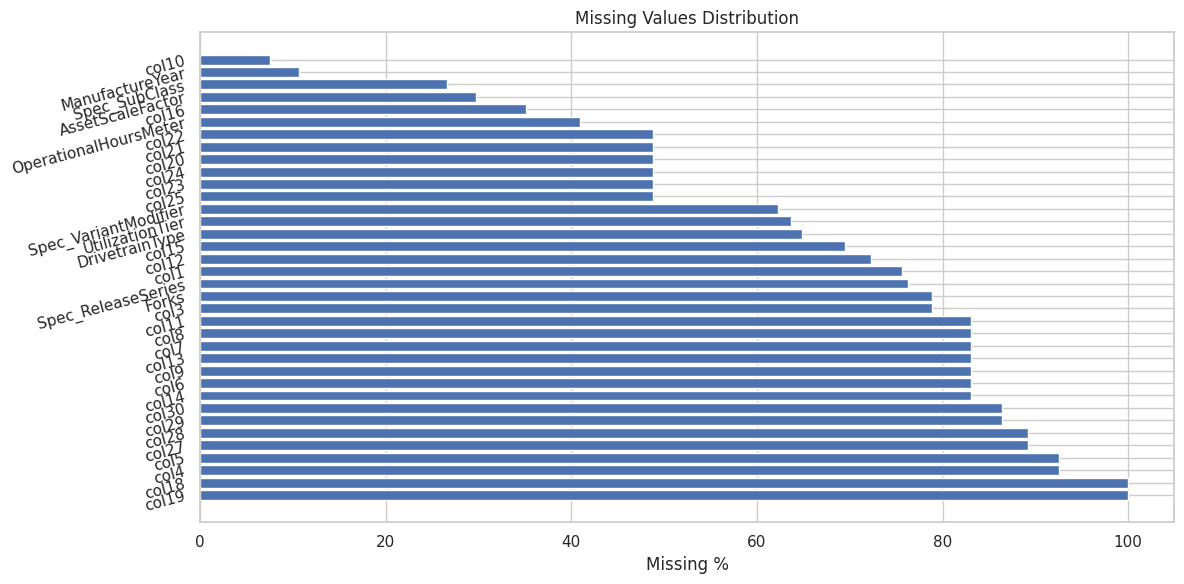

In [81]:
plt.figure(figsize=(12,6))
plt.yticks(rotation=15)
plt.barh(missing_summary[missing_summary['Missing_Count']>0]['Column'],missing_summary[missing_summary['Missing_Count']>0]['Missing_Percent'])
plt.xlabel('Missing %')
plt.title('Missing Values Distribution')
plt.tight_layout()

In [82]:
# Drop Columns with >80% Missing
high_missing_cols=missing_summary[missing_summary['Missing_Percent']>80]['Column'].tolist()
print('Columns to drop(>80% missing)',high_missing_cols)
df.drop(columns=high_missing_cols,inplace=True) ############
test.drop(columns=high_missing_cols,inplace=True)

Columns to drop(>80% missing) ['col19', 'col18', 'col4', 'col5', 'col27', 'col28', 'col29', 'col30', 'col14', 'col6', 'col9', 'col13', 'col7', 'col8', 'col11']


In [83]:
## these are ids and add little to no information to data
df.drop(['TransactionID','VendorPartnerID','DataOriginCode'],axis=1,inplace=True)
test.drop(['VendorPartnerID','DataOriginCode'],axis=1,inplace=True)

# 6.3 Miscellaneous

In [84]:
##inventory group category and InventoryGroupDescription look the same,to verify:
df['InventoryGroupCategory'].value_counts(),df['InventoryGroupDescription'].value_counts()

(InventoryGroupCategory
 TEX    70868
 MG     23367
 WL     18827
 TTT    14911
 BL     10352
 SSL       66
 Name: count, dtype: int64,
 InventoryGroupDescription
 Track Excavators       70868
 Motor Graders          23367
 Wheel Loader           18827
 Track Type Tractors    14911
 Backhoe Loaders        10352
 Skid Steer Loaders        66
 Name: count, dtype: int64)

In [85]:
## as expected,they are exactly same
df.drop('InventoryGroupDescription',axis=1,inplace=True)
test.drop('InventoryGroupDescription',axis=1,inplace=True)

In [86]:
for col in df.select_dtypes(include='object').columns:
    print(col,df[col].nunique())

UtilizationTier 3
Spec_FullDescriptor 3500
Spec_BaseClass 1247
Spec_SubClass 147
Spec_ReleaseSeries 113
Spec_VariantModifier 132
AssetScaleFactor 6
FunctionalClassification 65
RegionCode 53
InventoryGroupCategory 6
col1 4
CabinType 3
Forks 2
col3 3
DrivetrainType 8
col10 11
col12 4
col15 15
col16 3
col20 2
col21 18
col22 27
col23 3
col24 3
col25 3


Lets check why Spec_FullDescriptor has so many unique values

In [87]:
df[['Spec_FullDescriptor','Spec_BaseClass','Spec_SubClass','Spec_ReleaseSeries','Spec_VariantModifier']].head(20)

,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier
0,950FII,950,F,II,NaN
1,310G,310,G,NaN,NaN
2,790ELC,790,E,NaN,LC
3,416D,416,D,NaN,NaN
4,430HAG,430,HAG,NaN,NaN
5,988B,988,B,NaN,NaN
6,310G,310,G,NaN,NaN
7,PC200LC6,PC200,NaN,LC,6
8,420D,420,D,NaN,NaN
9,214E,214,E,NaN,NaN


Spec_FullDescriptor is clearly the combination of other spec features. WE WILL DELETE IT

In [88]:
df['col15'].unique(),df['col21'].unique(),df['col22'].unique(),df['col10'].unique()

(array(['23.5', nan, 'None or Unspecified', '13"', '26.5', '29.5', '14"',
        '20.5', '17.5"', '15.5"', '20.5"', '17.5', '23.5"', '10"', '15.5',
        '23.1"'], dtype=object),
 array([nan, 'None or Unspecified', '16 inch', '32 inch', '30 inch',
        '28 inch', '22 inch', '18 inch', '24 inch', '36 inch', '20 inch',
        '27 inch', '15 inch', '26 inch', '34 inch', '33 inch', '14 inch',
        '31 inch', '25 inch'], dtype=object),
 array([nan, 'None or Unspecified', '11\' 0"', '10\' 2"', '10\' 6"',
        '9\' 10"', '10\' 10"', '9\' 6"', '9\' 7"', '12\' 8"', '8\' 6"',
        '9\' 8"', '12\' 10"', '11\' 10"', '8\' 10"', '8\' 4"', '8\' 2"',
        '12\' 4"', '15\' 9"', '9\' 5"', '6\' 3"', '14\' 1"', '13\' 7"',
        '13\' 10"', '13\' 9"', '24\' 3"', '19\' 8"', '15\' 4"'],
       dtype=object),
 array(['2 Valve', nan, 'Standard', 'Auxiliary', 'Base + 1 Function',
        'Base + 3 Function', '4 Valve', '3 Valve', 'Base + 2 Function',
        'Base + 4 Function', 'Base + 5 F

In [89]:
##THIS CELK IS STANDARDISING THE CATEOGORICAL COLUMNS
for df_ in [df,test]: ##for iteration in both
    # col15: Remove "
    df_["col15"]=df_["col15"].replace("None or Unspecified",np.nan)
    df_["col15"]=df_["col15"].str.replace('"','',regex=False).astype(float)
    # col21: Remove "inch"
    df_["col21"]=df_["col21"].replace("None or Unspecified",np.nan)
    df_["col21"]=df_["col21"].str.replace("inch","",regex=False).str.strip().astype(float)
    # col22: Convert feet and inches to total inches
    df_["col22"]=df_["col22"].replace("None or Unspecified",np.nan)
    df_["col22"]=df_["col22"].apply(lambda x:np.nan if pd.isna(x) else int(str(x).split("'")[0])*12+int(str(x).split("'")[1].replace('"','').strip() or 0))
    # col10_count: Extract first number
    df_["col10_count"]=df_["col10"].str.extract(r"(\d+)").astype(float)

# 7. Feature Engineering

Feature engineering is the process of creating new variables from the existing dataset to better capture relationships that may improve model performance. Based on the insights obtained from the exploratory data analysis and domain knowledge,several numerical,categorical,and interaction features are constructed in this section.

We will be engineering the following features properly:

#### 7.1: Machine Age & Usage

1. MachineAge
2. ZeroHours
3. HoursPerYear
4. LogHoursPerYear
5. LogOperationalHours
6. IsNewMachine
7. HasOperationalHours
8. HasVariantModifier
#### 7.2: Spec & Text Parsing
9. DescriptorLength
10. ModelNumericalPrefix
#### 7.3: Categorical Combinations & Flags
11. TransactionSummer
12. UtilizationGroup
13. Region_x_BaseClass
14. Function_x_BaseClass
15. CoveredMachine
#### 7.4 — Leak-Safe Historical Price Features
16. rolling_avg_180d
17. rolling_avg_365d
18. rolling_avg_730d
19. rolling_avg_ratio
20. asset_prior_count
21. asset_prior_price
22. baseclass_prior_mean
23. and many more...

## 7.1 Machine Age & Usage

In [90]:
def add_hours_features(df_):
    """ This function creates Machine Age-related features for any dataframe."""
    #Machine Age
    df_['MachineAge']=df_['TransactionYear']-df_['ManufactureYear']
    #ZeroHours
    df_.loc[(df_["OperationalHoursMeter"] == 0)&(df_["MachineAge"] != 0),"OperationalHoursMeter"]=np.nan
    df_["ZeroHours"]=(df_["OperationalHoursMeter"] == 0).astype(int)
    #HoursPerYear
    df_['HoursPerYear']=df_['OperationalHoursMeter']/df_['MachineAge'].clip(lower=1)
    #LogHoursPerYear
    df_['LogHoursPerYear']=np.log1p(df_['HoursPerYear'])
    #LogOperationalHours
    df_['LogOperationalHours']=np.log1p(df_['OperationalHoursMeter'])
    #IsNewMachine
    df_["IsNewMachine"]=(df_["MachineAge"] < 5)
    #HasOperationalHours
    df_["HasOperationalHours"]=df_["OperationalHoursMeter"].notna().astype(int)
    #HasVariantModifier
    df_["HasVariantModifier"]=df_["Spec_VariantModifier"].notna().astype(int)
    return df_

def fill_operational_hours(df_,group_medians,global_median):
    #OperationalHoursMeter Changed
    df_['OperationalHoursMeter']=df_['OperationalHoursMeter'].fillna(df_['Spec_BaseClass'].map(group_medians)).fillna(global_median)
    return df_

df=add_hours_features(df)
test=add_hours_features(test)

group_medians=df.groupby('Spec_BaseClass')['OperationalHoursMeter'].median()
global_median=df['OperationalHoursMeter'].median()

df=fill_operational_hours(df,group_medians,global_median)
test=fill_operational_hours(test,group_medians,global_median)

## 7.2 Spec & Text Parsing

In [91]:
def add_spec_text_parsing_features(df_):
    """ This function creates Spec_FullDescriptor-related features for any dataframe."""
    #DescriptorLength
    df_["DescriptorLength"]=df_["Spec_FullDescriptor"].astype(str).apply(len)
    #ModelNumericPrefix
    df_["ModelNumericPrefix"]=df_["Spec_FullDescriptor"].astype(str).str.extract(r"^(\d+)").astype(float)
    #dropping Spec_FullDescriptor as it is now useless and we've derived all important details out of it
    df_.drop('Spec_FullDescriptor',axis=1,inplace=True)
    return df_

df=add_spec_text_parsing_features(df)
test=add_spec_text_parsing_features(test)

## 7.3: Categorical Combinations & Flags

In [92]:
def add_categorical_grouping_features(df_):
    """ This function creates seasonal, utilization, and interaction categorical features for any dataframe."""
    #TransactionSummer
    df_['TransactionSummer']=(df_['TransactionMonth'] < 6).astype(int)
    #UtilizationGroup
    df_.loc[df_["HoursPerYear"]<=500,"UtilizationGroup"]="VeryLow"
    df_.loc[(df_["HoursPerYear"]>500)&(df_["HoursPerYear"]<=1000),"UtilizationGroup"]="Low"
    df_.loc[(df_["HoursPerYear"]>1000)&(df_["HoursPerYear"]<=2000),"UtilizationGroup"]="Medium"
    df_.loc[(df_["HoursPerYear"]>2000)&(df_["HoursPerYear"]<=5000),"UtilizationGroup"]="High"
    df_.loc[df_["HoursPerYear"]>5000,"UtilizationGroup"]="VeryHigh"
    #CoveredMachine
    df_["CoveredMachine"]=df_["CabinType"].isin(["EROPS","EROPS w AC"])
    #Region_X_BaseClass
    df_["Region_x_BaseClass"]=df_["RegionCode"].astype(str)+"_"+df_["Spec_BaseClass"].astype(str)
    #Function_X_BaseCLass
    df_["Function_x_BaseClass"]=df_["FunctionalClassification"].astype(str)+"_"+df_["Spec_BaseClass"].astype(str)
    return df_

df=add_categorical_grouping_features(df)
test=add_categorical_grouping_features(test)

## 7.4: Leak -Safe Historical Price Features

Every feature below only uses information that would genuinely have been known at the time of each transaction no feature here ever looks at its own row's price or at anything dated on or after it.

In [93]:
def build_rolling_lookup(df):
    """ This function builds the leak-safe cumulative sum/count lookup table for rolling average features, using train data only."""
    df=df.sort_values("TransactionDate").reset_index(drop=True)
    overall_mean=df["TargetValue"].mean()
    daily=df.groupby(["ProductConfigID","TransactionDate"],as_index=False)["TargetValue"].agg(
        day_sum="sum",day_count="count"
    )
    daily=daily.sort_values(["ProductConfigID","TransactionDate"])
    daily["cum_sum"]=daily.groupby("ProductConfigID")["day_sum"].cumsum()
    daily["cum_count"]=daily.groupby("ProductConfigID")["day_count"].cumsum()
    lookup=daily[["ProductConfigID","TransactionDate","cum_sum","cum_count"]].sort_values("TransactionDate")
    return df,lookup,overall_mean

def add_rolling_avg(df_,lookup,overall_mean,window_days,col_name):
    """ This function applies the rolling average lookup to any dataframe for a given window length."""
    f=df_.reset_index().sort_values("TransactionDate")
    upper=pd.merge_asof(f,lookup,on="TransactionDate",by="ProductConfigID",
                           direction="backward",allow_exact_matches=False)
    f2=f.copy()
    f2["TransactionDate"]=f2["TransactionDate"] - pd.Timedelta(days=window_days)
    lower=pd.merge_asof(f2.sort_values("TransactionDate"),lookup,on="TransactionDate",by="ProductConfigID",
                           direction="backward",allow_exact_matches=False).sort_values("index").reset_index(drop=True)
    upper=upper.sort_values("index").reset_index(drop=True)
    roll_sum=(upper["cum_sum"].fillna(0) - lower["cum_sum"].fillna(0)).values
    roll_count=(upper["cum_count"].fillna(0) - lower["cum_count"].fillna(0)).values
    val_sum=pd.Series(roll_sum,index=upper["index"].values).sort_index()
    val_count=pd.Series(roll_count,index=upper["index"].values).sort_index()
    df_[col_name]=np.where(val_count.values > 0,val_sum.values / val_count.values.clip(min=1),overall_mean)
    return df_

df,lookup,overall_mean=build_rolling_lookup(df)
test=test.sort_values("TransactionDate").reset_index(drop=True)

df=add_rolling_avg(df,lookup,overall_mean,180,"rolling_avg_180d")
test=add_rolling_avg(test,lookup,overall_mean,180,"rolling_avg_180d")

In [94]:
## Rolling Avergae 365 days
df=add_rolling_avg(df,lookup,overall_mean,365,"rolling_avg_365d")
test=add_rolling_avg(test,lookup,overall_mean,365,"rolling_avg_365d")

In [95]:
## Rolling Average 730 days; AS THESE FEATURES HAVE VERY HIGH FEATURE IMPORTANCE
df=add_rolling_avg(df,lookup,overall_mean,730,"rolling_avg_730d")
test=add_rolling_avg(test,lookup,overall_mean,730,"rolling_avg_730d")

In [96]:
df=add_rolling_avg(df,lookup,overall_mean,90,"rolling_avg_90d")
test=add_rolling_avg(test,lookup,overall_mean,90,"rolling_avg_90d")

In [97]:
df["rolling_avg_trend"]=df["rolling_avg_365d"]-df["rolling_avg_730d"]
test["rolling_avg_trend"]=test["rolling_avg_365d"]-test["rolling_avg_730d"]## Rolling average trend — momentum signal from existing rolling averages, no leakage risk (pure arithmetic)
df["rolling_avg_trend"]=df["rolling_avg_365d"]-df["rolling_avg_730d"]
test["rolling_avg_trend"]=test["rolling_avg_365d"]-test["rolling_avg_730d"]

In [98]:
def add_rolling_count(df_,lookup,window_days,col_name):
    """ Computes the leak-safe rolling transaction count for a window, using the same lookup table as add_rolling_avg. """
    f=df_.reset_index().sort_values("TransactionDate")
    upper=pd.merge_asof(f,lookup,on="TransactionDate",by="ProductConfigID",
                           direction="backward",allow_exact_matches=False)
    f2=f.copy()
    f2["TransactionDate"]=f2["TransactionDate"] - pd.Timedelta(days=window_days)
    lower=pd.merge_asof(f2.sort_values("TransactionDate"),lookup,on="TransactionDate",by="ProductConfigID",
                           direction="backward",allow_exact_matches=False).sort_values("index").reset_index(drop=True)
    upper=upper.sort_values("index").reset_index(drop=True)
    roll_count=(upper["cum_count"].fillna(0) - lower["cum_count"].fillna(0)).values
    val_count=pd.Series(roll_count,index=upper["index"].values).sort_index()
    df_[col_name]=val_count.values
    return df_

df=add_rolling_count(df,lookup,365,"rolling_count_365d")
test=add_rolling_count(test,lookup,365,"rolling_count_365d")

In [99]:
def add_rolling_avg_ratio(df_):
    #rolling_avg_ratio
    df_["rolling_avg_ratio"]=df_["rolling_avg_180d"]/df_["rolling_avg_365d"].replace(0,np.nan)
    df_["rolling_avg_ratio"]=df_["rolling_avg_ratio"].fillna(1.0)
    return df_

df=add_rolling_avg_ratio(df)
test=add_rolling_avg_ratio(test)

In [100]:
def build_asset_lookup(df):
    """ This function creates AssetID prior count/price features on train and builds the lookup table for test."""
    
    df["asset_prior_count"]=df.groupby("AssetID").cumcount()
    df["asset_prior_price"]=df.groupby("AssetID")["TargetValue"].shift(1)
    asset_lookup=df[["AssetID","TransactionDate","TargetValue"]].copy()
    asset_lookup["asset_cum_count"]=asset_lookup.groupby("AssetID").cumcount() + 1
    asset_lookup=asset_lookup.sort_values("TransactionDate")
    return df,asset_lookup

def apply_asset_prior(test,asset_lookup):
    """ This function applies the AssetID prior count/price lookup to the test dataframe."""
    
    test_sorted=test.reset_index().sort_values("TransactionDate")
    merged=pd.merge_asof(
        test_sorted,asset_lookup,
        on="TransactionDate",by="AssetID",
        direction="backward",allow_exact_matches=False
    )
    merged=merged.set_index("index").sort_index()
    test["asset_prior_count"]=merged["asset_cum_count"].fillna(0).astype(int)
    test["asset_prior_price"]=merged["TargetValue"]
    return test

df,asset_lookup=build_asset_lookup(df)
test=apply_asset_prior(test,asset_lookup)

In [101]:
def build_baseclass_lookup(df,overall_mean):
    """ This function creates the Spec_BaseClass prior mean feature on train and builds the lookup table for test."""
    
    daily=df.groupby(["Spec_BaseClass","TransactionDate"],as_index=False)["TargetValue"].agg(day_sum="sum",day_count="count")
    daily=daily.sort_values(["Spec_BaseClass","TransactionDate"])
    daily["cum_sum"]=daily.groupby("Spec_BaseClass")["day_sum"].cumsum()
    daily["cum_count"]=daily.groupby("Spec_BaseClass")["day_count"].cumsum()
    daily["prior_sum"]=daily.groupby("Spec_BaseClass")["cum_sum"].shift(1)
    daily["prior_count"]=daily.groupby("Spec_BaseClass")["cum_count"].shift(1)
    df=df.merge(daily[["Spec_BaseClass","TransactionDate","prior_sum","prior_count"]],on=["Spec_BaseClass","TransactionDate"],how="left")
    df["baseclass_prior_mean"]=(df["prior_sum"] / df["prior_count"]).fillna(overall_mean)
    df=df.drop(columns=["prior_sum","prior_count"])
    lookup=daily[["Spec_BaseClass","TransactionDate","cum_sum","cum_count"]].sort_values("TransactionDate")
    return df,lookup

def apply_baseclass_prior(test,lookup,overall_mean):
    """ This function applies the Spec_BaseClass prior mean lookup to the test dataframe."""
    
    test_sorted=test.reset_index().sort_values("TransactionDate")
    merged=pd.merge_asof(test_sorted,lookup,on="TransactionDate",by="Spec_BaseClass",direction="backward",allow_exact_matches=False)
    merged=merged.set_index("index").sort_index()
    test["baseclass_prior_mean"]=(merged["cum_sum"] / merged["cum_count"]).fillna(overall_mean)
    return test

df,lookup=build_baseclass_lookup(df,overall_mean)
test=apply_baseclass_prior(test,lookup,overall_mean)

In [102]:
def build_prior_mean_lookup(df, group_col, feature_name, overall_mean):
    """ Generalized version of build_baseclass_lookup — creates a leak-safe prior-mean price feature for any categorical group_col. """
    daily=df.groupby([group_col,"TransactionDate"],as_index=False)["TargetValue"].agg(day_sum="sum",day_count="count")
    daily=daily.sort_values([group_col,"TransactionDate"])
    daily["cum_sum"]=daily.groupby(group_col)["day_sum"].cumsum()
    daily["cum_count"]=daily.groupby(group_col)["day_count"].cumsum()
    daily["prior_sum"]=daily.groupby(group_col)["cum_sum"].shift(1)
    daily["prior_count"]=daily.groupby(group_col)["cum_count"].shift(1)
    df=df.merge(daily[[group_col,"TransactionDate","prior_sum","prior_count"]],on=[group_col,"TransactionDate"],how="left")
    df[feature_name]=(df["prior_sum"]/df["prior_count"]).fillna(overall_mean)
    df=df.drop(columns=["prior_sum","prior_count"])
    lookup=daily[[group_col,"TransactionDate","cum_sum","cum_count"]].sort_values("TransactionDate")
    return df,lookup

def apply_prior_mean(test,lookup,group_col,feature_name,overall_mean):
    """ Applies the prior-mean lookup to the test dataframe for the given group_col. """
    test_sorted=test.reset_index().sort_values("TransactionDate")
    merged=pd.merge_asof(test_sorted,lookup,on="TransactionDate",by=group_col,direction="backward",allow_exact_matches=False)
    merged=merged.set_index("index").sort_index()
    test[feature_name]=(merged["cum_sum"]/merged["cum_count"]).fillna(overall_mean)
    return test

# FunctionalClassification prior mean
df,func_lookup=build_prior_mean_lookup(df,"FunctionalClassification","functionalclass_prior_mean",overall_mean)
test=apply_prior_mean(test,func_lookup,"FunctionalClassification","functionalclass_prior_mean",overall_mean)

# RegionCode prior mean
df,region_lookup=build_prior_mean_lookup(df,"RegionCode","region_prior_mean",overall_mean)
test=apply_prior_mean(test,region_lookup,"RegionCode","region_prior_mean",overall_mean)

In [103]:
# Combined BaseClass x Region key
df["BaseClass_Region_Key"]=df["Spec_BaseClass"].astype(str)+"_"+df["RegionCode"].astype(str)
test["BaseClass_Region_Key"]=test["Spec_BaseClass"].astype(str)+"_"+test["RegionCode"].astype(str)

df,baseclass_region_lookup=build_prior_mean_lookup(df,"BaseClass_Region_Key","baseclass_x_region_prior_mean",overall_mean)
test=apply_prior_mean(test,baseclass_region_lookup,"BaseClass_Region_Key","baseclass_x_region_prior_mean",overall_mean)

In [104]:
df,subclass_lookup=build_prior_mean_lookup(df,"Spec_SubClass","spec_subclass_prior_mean",overall_mean)
test=apply_prior_mean(test,subclass_lookup,"Spec_SubClass","spec_subclass_prior_mean",overall_mean)

In [105]:
df,cabintype_lookup=build_prior_mean_lookup(df,"CabinType","cabintype_prior_mean",overall_mean)
test=apply_prior_mean(test,cabintype_lookup,"CabinType","cabintype_prior_mean",overall_mean)

In [106]:
df,func_baseclass_lookup=build_prior_mean_lookup(df,"Function_x_BaseClass","function_x_baseclass_prior_mean",overall_mean)
test=apply_prior_mean(test,func_baseclass_lookup,"Function_x_BaseClass","function_x_baseclass_prior_mean",overall_mean)

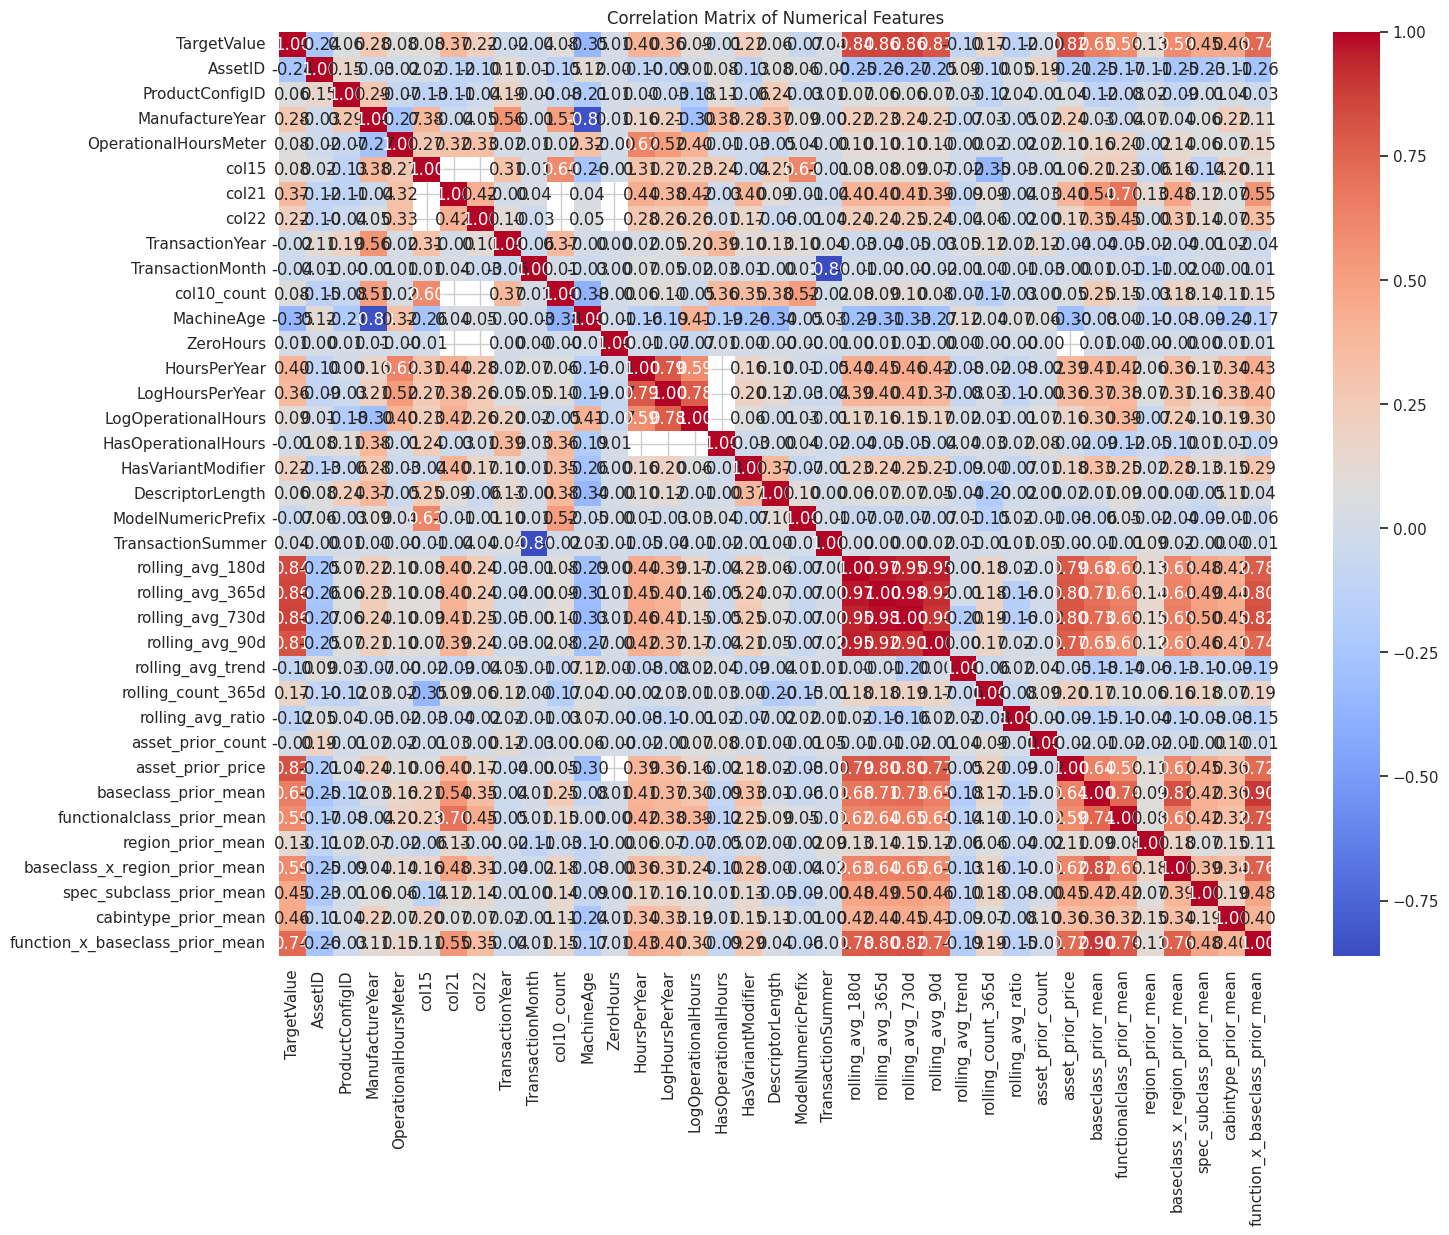

In [107]:
num_cols=df.select_dtypes(include=["number"]).columns
corr=df[num_cols].corr()
plt.figure(figsize=(16,12))
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# 8. Data Preprocessing

After feature engineering,the dataset is prepared for model development. This stage involves removing unnecessary features,separating the predictors from the target variable,and creating training and validation sets for model evaluation.

## 8.1 Removing Non-Predictive Features

Certain columns are excluded from model training because they either serve as unique identifiers or have already been transformed into more informative engineered features.

The following columns are removed:

- `ProductConfigID` – Unique product identifier with extremely high cardinality.
- `AssetID` – Unique identifier for each machine.
- `TransactionDate` – Replaced by engineered temporal features such as transaction year,month,and quarter.

In [108]:
df.drop(['ProductConfigID','AssetID','TransactionDate'],axis=1,inplace=True)
test.drop(['ProductConfigID','AssetID','TransactionDate'],axis=1,inplace=True)

## 8.2 Feature and Target Separation

The dataset is divided into predictor variables (`X`) and the target variable (`y`). The target variable (`TargetValue`) is excluded from the feature matrix to prevent data leakage during model training.

In [109]:
X=df.drop(columns=["TargetValue"])
y=df["TargetValue"]

## 8.3 Memory Optimization

After separating the feature matrix and target variable,the original training dataframe is no longer required. It is deleted from memory to reduce RAM usage during model training,particularly for computationally intensive gradient boosting models.

In [110]:
del df
gc.collect()

93342

## 8.4 Train–Validation Split

The training dataset is divided into training and validation subsets. The validation set is used to evaluate model performance and tune hyperparameters before generating predictions on the unseen test dataset.

In [111]:
X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.15,random_state=42,shuffle=True)

### Configuration

- Training set: **85%**
- Validation size: **15%**
- Random state: **42**
- Shuffle: **Enabled**

## 8.5 Target Transformation

The target variable exhibits a positively skewed distribution. A logarithmic transformation (`log1p`) is applied to stabilize the variance and reduce the influence of extreme values during model training.
This is also done because RMLSE is the metric,so this will improve our performance

In [112]:
y_train_log=np.log1p(y_train)
y_val_log=np.log1p(y_val)

# 9. Model Development
We shall now introduce 7 models to be compared. These 7 models are as follows:
- Linear Regression
- KNN Regressor
- AdaBoost
- RandomForestRegressor
- XGBoost
- LightGBM
- Catboost

We will blend results of the 3 best models out of these 7 models for final predictions.

In [113]:
cat_cols_all=list(X_train.select_dtypes(include=["object","bool"]).columns)
num_col=[c for c in X_train.columns if c not in cat_cols_all]

# col25 and UtilizationTier get a dedicated ordinal encoders below,so exclude them here
remaining_cat_cols=[c for c in cat_cols_all if c not in ["col25","UtilizationTier"]]
low_card_cat_cols=[c for c in remaining_cat_cols if X_train[c].nunique() < 50]
high_card_cat_cols=[c for c in remaining_cat_cols if c not in low_card_cat_cols]

num_pipe=Pipeline([('imputer',SimpleImputer(strategy='median'))])
high_card_cat_pipe=Pipeline([
    ('imputer',SimpleImputer(strategy='constant',fill_value='Missing')),
    ('encoder',TargetEncoder(target_type="continuous",cv=5,smooth="auto",random_state=42))
])
low_card_cat_pipe=Pipeline([
    ('imputer',SimpleImputer(strategy='constant',fill_value='Missing')),
    ('encoder',OneHotEncoder(handle_unknown="ignore",sparse_output=False))
])
col25_pipe=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OrdinalEncoder(categories=[["Single","Double","Triple"]]))
])
utilization_pipe=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OrdinalEncoder(categories=[["Low","Medium","High"]]))
])

preprocessing=ColumnTransformer(transformers=[
    ('num',num_pipe,num_col),
    ('low_cat',low_card_cat_pipe,low_card_cat_cols),
    ('high_cat',high_card_cat_pipe,high_card_cat_cols),
    ('col25_ord',col25_pipe,['col25']),
    ('utilization_ord',utilization_pipe,['UtilizationTier'])
])

## 9.1 Linear Regression

In [114]:
linreg=LinearRegression()
pipeline_linreg=Pipeline([("preprocessor",preprocessing),("scaler",StandardScaler()),("model",linreg)])

In [115]:
pipeline_linreg.fit(X_train,y_train_log)
linreg_y_val_pred=np.expm1(pipeline_linreg.predict(X_val))
linreg_y_val_pred=np.maximum(linreg_y_val_pred,0)
rmsle_linreg=root_mean_squared_log_error(y_val,linreg_y_val_pred)
rmsle_linreg

0.28605133423546675

## 9.2 KNN Regressor

In [116]:
knn=KNeighborsRegressor(n_neighbors=15,n_jobs=-1,algorithm="brute")
pipeline_knn=Pipeline([("preprocessor",preprocessing),("scaler",StandardScaler()),("model",knn)])

In [117]:
pipeline_knn.fit(X_train,y_train_log)
knn_y_val_pred=np.expm1(pipeline_knn.predict(X_val))
knn_y_val_pred=np.maximum(knn_y_val_pred,0)
rmsle_knn=root_mean_squared_log_error(y_val,knn_y_val_pred)
rmsle_knn

0.2829865262998425

## 9.3 AdaBoost

In [118]:
ada=AdaBoostRegressor(n_estimators=1000,random_state=42)
pipeline_ada=Pipeline([('preprocessor',preprocessing),('model',ada)])

In [119]:
pipeline_ada.fit(X_train,y_train_log)
ada_y_val_pred=np.expm1(pipeline_ada.predict(X_val))
ada_y_val_pred=np.maximum(ada_y_val_pred,0)
rmsle_ada=root_mean_squared_log_error(y_val,ada_y_val_pred)
rmsle_ada

0.337733092741679

## 9.4 Random Forest

In [120]:
rf=RandomForestRegressor(n_estimators=200,random_state=42,n_jobs=-1)
pipeline_rf=Pipeline([('preprocessor',preprocessing),('model',rf)])

In [121]:
pipeline_rf.fit(X_train,y_train_log)
rf_y_val_pred=np.expm1(pipeline_rf.predict(X_val))
rf_y_val_pred=np.maximum(rf_y_val_pred,0)
rmsle_rf=root_mean_squared_log_error(y_val,rf_y_val_pred)
rmsle_rf

0.21996988743080567

## 9.5 XGBoost

In [122]:
xgb=XGBRegressor(n_estimators=1000,learning_rate=0.1,max_depth=6,random_state=42,)
pipeline_xgb=Pipeline([("preprocessor",preprocessing),("model",xgb)])

In [123]:
pipeline_xgb.fit(X_train,y_train_log)
xgb_y_val_pred=np.expm1(pipeline_xgb.predict(X_val))
xgb_y_val_pred=np.maximum(xgb_y_val_pred,0)
rmsle_xgb=root_mean_squared_log_error(y_val,xgb_y_val_pred)
rmsle_xgb

0.21065309686294392

## 9.6 LightGBM

In [124]:
lgbm=lgb.LGBMRegressor(n_estimators=1000,learning_rate=0.1,max_depth=6,random_state=42,verbose=-1)
pipeline_lgbm=Pipeline([("preprocessor",preprocessing),("model",lgbm)])

In [125]:
pipeline_lgbm.fit(X_train,y_train_log)
lgbm_y_val_pred=np.expm1(pipeline_lgbm.predict(X_val))
lgbm_y_val_pred=np.maximum(lgbm_y_val_pred,0)
rmsle_lgbm=root_mean_squared_log_error(y_val,lgbm_y_val_pred)
rmsle_lgbm

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


0.2125642638022079

## 9.7 Catboost

In [126]:
catb=CatBoostRegressor(iterations=2000,learning_rate=0.1,depth=6,random_seed=42,verbose=False)
pipeline_catb=Pipeline([("preprocessor",preprocessing),("model",catb)])

In [127]:
pipeline_catb.fit(X_train,y_train_log)
catb_y_val_pred=np.expm1(pipeline_catb.predict(X_val))
catb_y_val_pred=np.maximum(catb_y_val_pred,0)
rmsle_catb=root_mean_squared_log_error(y_val,catb_y_val_pred)
rmsle_catb

0.21224879907300237

## 9.8 Model Comparision before tuning

In [128]:
results=pd.DataFrame({
    "Model":["AdaBoost","Random Forest","XGBoost","LightGBM","CatBoost","KNN","Linear Regression"],
    "Val_RMSLE":[rmsle_ada,rmsle_rf,rmsle_xgb,rmsle_lgbm,rmsle_catb,rmsle_knn,rmsle_linreg],
})
results=results.sort_values("Val_RMSLE").reset_index(drop=True)
results

,Model,Val_RMSLE
0,XGBoost,0.210653
1,CatBoost,0.212249
2,LightGBM,0.212564
3,Random Forest,0.219970
4,KNN,0.282987
5,Linear Regression,0.286051
6,AdaBoost,0.337733


### Observations:
We will be selecting top 3 performing models for final predictions i.e.:
- XGBoost
- Catboost
- LightGBM

# 10. Hyperparameter Tuning

Hyperparameter tuning is performed to identify the optimal configuration for each machine learning model. By systematically searching different parameter combinations, the models are refined to achieve better predictive performance while reducing the risk of overfitting.

## 10.1: For boosting models, configuring usable lists

In [129]:
cat_cols=list(X_train.select_dtypes(include=["object","bool"]).columns)
print("Categorical columns:",cat_cols)

for col in cat_cols:
    X_train[col]=X_train[col].fillna("Missing").astype(str)
    X_val[col]=X_val[col].fillna("Missing").astype(str)
    test[col]=test[col].fillna("Missing").astype(str)

Categorical columns: ['UtilizationTier', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory', 'col1', 'CabinType', 'Forks', 'col3', 'DrivetrainType', 'col10', 'col12', 'col16', 'col20', 'col23', 'col24', 'col25', 'IsNewMachine', 'UtilizationGroup', 'CoveredMachine', 'Region_x_BaseClass', 'Function_x_BaseClass', 'BaseClass_Region_Key']


In [130]:
xgb_cat_dtypes={}
for col in cat_cols:
    all_values=pd.concat([X_train[col],X_val[col],test[col]]).unique()
    xgb_cat_dtypes[col]=pd.CategoricalDtype(categories=all_values)

In [131]:
X_train_lgb=X_train.copy()
X_val_lgb=X_val.copy()
X_train_xgb=X_train.copy()
X_val_xgb=X_val.copy()
for col in cat_cols:
    X_train_lgb[col]=X_train_lgb[col].astype("category")
    X_val_lgb[col]=X_val_lgb[col].astype("category")
    X_train_xgb[col]=X_train_xgb[col].astype(xgb_cat_dtypes[col])
    X_val_xgb[col]=X_val_xgb[col].astype(xgb_cat_dtypes[col])

## 10.2 HPT for all three

Full hpt has been performed in version 132 and can be seen.

In [132]:
## I had used this earlier and saved best params
'''#Catboost
cat_param_grid={
    "learning_rate": [0.025,0.03,0.035],
    "depth": [5,6,7,8],
    "l2_leaf_reg": [1,2,3,5],
    "min_data_in_leaf": [5,20,50],
}

cat_base=CatBoostRegressor(
    iterations=20000,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    task_type="CPU",
    boosting_type="Plain",
    thread_count=-1,
    verbose=False,
)

cat_search=RandomizedSearchCV(
    cat_base,cat_param_grid,
    n_iter=5,cv=2,scoring="neg_root_mean_squared_error",
    random_state=123,verbose=2,n_jobs=1,
)

# Sampling 40% of training data for the search phase to cut runtime
X_train_sample=X_train.sample(frac=0.4,random_state=42)
y_train_sample=y_train_log.loc[X_train_sample.index]

cat_search.fit(X_train_sample,y_train_sample,cat_features=cat_cols,eval_set=(X_val,y_val_log),early_stopping_rounds=200)

print("Best CatBoost params:",cat_search.best_params_)
print("Best CatBoost CV RMSLE:",-cat_search.best_score_)'''

#Output:
'''Best CatBoost params: {'min_data_in_leaf': 5, 'learning_rate': 0.025, 'l2_leaf_reg': 2, 'depth': 8}'''

"Best CatBoost params: {'min_data_in_leaf': 5, 'learning_rate': 0.025, 'l2_leaf_reg': 2, 'depth': 8}"

In [133]:
'''#LightGBM
lgbm_param_grid={
    "learning_rate": [0.025,0.03,0.035],
    "num_leaves": [200,300,400],
    "lambda_l1": [0.5,1,5],
    "lambda_l2": [1,5,10],
    "min_child_samples": [5,10,20]
}

lgbm_base=lgb.LGBMRegressor(
    n_estimators=15000,
    objective="regression",
    metric="rmse",
    feature_fraction=0.85,
    bagging_fraction=0.85,
    bagging_freq=1,
    num_threads=-1,
    random_state=42,
    verbose=-1,
)

lgbm_search=RandomizedSearchCV(
    lgbm_base,lgbm_param_grid,
    n_iter=5,cv=3,scoring="neg_root_mean_squared_error",
    random_state=42,verbose=2,n_jobs=1,
)

# Sampling 80% of training data for the search phase to cut runtime
X_train_lgb_sample=X_train_lgb.sample(frac=0.8,random_state=42)
y_train_sample=y_train_log.loc[X_train_lgb_sample.index]

lgbm_search.fit(
    X_train_lgb_sample,y_train_sample,
    eval_set=[(X_val_lgb,y_val_log)],
    callbacks=[lgb.early_stopping(200,verbose=False)],
    categorical_feature=cat_cols,
)

print("Best LightGBM params:",lgbm_search.best_params_)
print("Best LightGBM CV RMSLE:",-lgbm_search.best_score_)'''
#Output:
'''lgbm_best_params = {"num_leaves": 400, "min_child_samples": 20, "learning_rate": 0.03, "lambda_l2": 10, "lambda_l1": 1}'''

'lgbm_best_params = {"num_leaves": 400, "min_child_samples": 20, "learning_rate": 0.03, "lambda_l2": 10, "lambda_l1": 1}'

In [134]:
'''## XGBoost
xgb_param_grid={
    "learning_rate": [0.02,0.025,0.03,0.035],
    "max_depth": [6,7,8,9,10],
    "min_child_weight": [0.5,1,3],
    "reg_alpha": [1,5,10],
    "reg_lambda": [0.5,1,5],
}

xgb_base=XGBRegressor(
    n_estimators=10000,
    subsample=0.85,
    colsample_bytree=0.85,
    tree_method="hist",
    n_jobs=-1,
    enable_categorical=True,
    eval_metric="rmse",
    early_stopping_rounds=200,
    random_state=42,
)

xgb_search=RandomizedSearchCV(
    xgb_base,xgb_param_grid,
    n_iter=5,cv=2,scoring="neg_root_mean_squared_error",
    random_state=42,verbose=2,n_jobs=1,
)

# Sampling 80% of training data for the search phase to cut runtime
X_train_xgb_sample=X_train_xgb.sample(frac=0.8,random_state=42)
y_train_sample=y_train_log.loc[X_train_xgb_sample.index]

xgb_search.fit(X_train_xgb_sample,y_train_sample,eval_set=[(X_val_xgb,y_val_log)],verbose=False)

print("Best XGBoost params:",xgb_search.best_params_)
print("Best XGBoost CV RMSLE:",-xgb_search.best_score_)'''
#output:
'''xgb_best_params = {"reg_lambda": 0.5, "reg_alpha": 5, "min_child_weight": 3, "max_depth": 9, "learning_rate": 0.02}'''

'xgb_best_params = {"reg_lambda": 0.5, "reg_alpha": 5, "min_child_weight": 3, "max_depth": 9, "learning_rate": 0.02}'

In [135]:
# Best hyperparameters found previously via RandomizedSearchCV — hardcoded to skip re-searching
cat_best_params = {"min_data_in_leaf": 5, "learning_rate": 0.025, "l2_leaf_reg": 2, "depth": 8}
lgbm_best_params = {"num_leaves": 400, "min_child_samples": 20, "learning_rate": 0.03, "lambda_l2": 10, "lambda_l1": 1}
xgb_best_params = {"reg_lambda": 0.5, "reg_alpha": 5, "min_child_weight": 3, "max_depth": 9, "learning_rate": 0.02}

## 10.3: Using the tuned model on X_train and y_train

In [136]:
'''## catboost
cat_model=CatBoostRegressor(
    iterations=30000,
    learning_rate=0.025,
    depth=8,
    l2_leaf_reg=2,
    min_data_in_leaf=5,
    loss_function="RMSE",
    eval_metric="RMSE",
    cat_features=cat_cols,
    random_seed=42,
    task_type="CPU",
    boosting_type="Plain",
    thread_count=-1,
    early_stopping_rounds=200,
    verbose=200,
)
cat_model.fit(X_train, y_train_log, eval_set=(X_val, y_val_log))
cat_val_pred_log=cat_model.predict(X_val)
cat_rmsle=root_mean_squared_log_error(y_val, np.expm1(cat_val_pred_log))
print("CatBoost val RMSLE:", cat_rmsle)
print("Best iteration:", cat_model.get_best_iteration())'''
#output:
CAT_ITERATIONS = 25464

In [137]:
'''#LightGBM
lgb_model=lgb.LGBMRegressor(
    objective="regression",
    metric="rmse",
    n_estimators=10000,
    learning_rate=lgbm_search.best_params_["learning_rate"],
    num_leaves=lgbm_search.best_params_["num_leaves"],
    max_depth=-1,
    min_child_samples=lgbm_search.best_params_["min_child_samples"],
    feature_fraction=0.85,
    bagging_fraction=0.85,
    bagging_freq=1,
    reg_alpha=lgbm_search.best_params_["lambda_l1"],
    reg_lambda=lgbm_search.best_params_["lambda_l2"],
    num_threads=-1,
    random_state=42,
    verbose=-1,
)

lgb_model.fit(
    X_train_lgb, y_train_log,
    eval_set=[(X_val_lgb, y_val_log)],
    eval_metric="rmse",
    categorical_feature=cat_cols,
    callbacks=[lgb.early_stopping(200), lgb.log_evaluation(200)],
)
lgb_val_pred_log=lgb_model.predict(X_val_lgb, num_iteration=lgb_model.best_iteration_)
lgb_rmsle=root_mean_squared_log_error(y_val, np.expm1(lgb_val_pred_log))
print("LightGBM val RMSLE:", lgb_rmsle)
print("Best iteration:", lgb_model.best_iteration_)'''
#output:
LGB_ITERATIONS = 1512

In [138]:
'''#XGBoost
xgb_model=XGBRegressor(
    n_estimators=10000,
    learning_rate=xgb_search.best_params_["learning_rate"],
    max_depth=xgb_search.best_params_["max_depth"],
    min_child_weight=xgb_search.best_params_["min_child_weight"],
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=xgb_search.best_params_["reg_alpha"],
    reg_lambda=xgb_search.best_params_["reg_lambda"],
    tree_method="hist",
    enable_categorical=True,
    eval_metric="rmse",
    early_stopping_rounds=200,
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(X_train_xgb, y_train_log, eval_set=[(X_val_xgb, y_val_log)], verbose=0)
xgb_val_pred_log=xgb_model.predict(X_val_xgb)
xgb_rmsle=root_mean_squared_log_error(y_val, np.expm1(xgb_val_pred_log))
print("XGBoost val RMSLE:", xgb_rmsle)
print("Best iteration:", xgb_model.best_iteration)'''
#output:
XGB_ITERATIONS = 9291

## 10.4: Looking for best blending weight

In [139]:
'''best_rmsle=np.inf
best_weights=None

grid=np.round(np.arange(0,1.01,0.02),2)
for w_cat in grid:
    for w_lgb in grid:
        w_xgb=round(1-w_cat-w_lgb,2)
        if w_xgb < 0 or w_xgb > 1:
            continue
        blend_log=w_cat * cat_val_pred_log+w_lgb * lgb_val_pred_log+w_xgb * xgb_val_pred_log
        blend_rmsle=root_mean_squared_log_error(y_val,np.expm1(blend_log))
        if blend_rmsle < best_rmsle:
            best_rmsle=blend_rmsle
            best_weights=(w_cat,w_lgb,w_xgb)

print("CatBoost: {:.5f}  LightGBM: {:.5f}  XGBoost: {:.5f}".format(cat_rmsle,lgb_rmsle,xgb_rmsle))
print("Best blend weights (cat,lgb,xgb):",best_weights)
print("Best blend val RMSLE:",best_rmsle)'''
#Output:
best_weights=(0.54,0.34,0.12)  # (cat,lgb,xgb) — found previously, val RMSLE 0.19899

# 11. Final Prediction

After selecting the optimal model configurations and ensemble weights, the models are retrained using the complete training dataset. The final predictions are generated for the unseen test dataset, transformed back to the original scale, and formatted according to the competition submission requirements.

## 11.1 Refitting on Full Data

In [140]:
test_ids=test["TransactionID"].copy()

X_full=X.copy()
test_full=test.drop(columns=["TransactionID"])

y_full_log=np.log1p(y)

for col in cat_cols:
    X_full[col]=X_full[col].fillna("Missing").astype(str)
    test_full[col]=test_full[col].fillna("Missing").astype(str)

In [141]:
## CatBoost
cat_full=CatBoostRegressor(
    iterations=CAT_ITERATIONS,
    learning_rate=cat_best_params["learning_rate"], 
    depth=cat_best_params["depth"],
    l2_leaf_reg=cat_best_params["l2_leaf_reg"],
    min_data_in_leaf=cat_best_params["min_data_in_leaf"],
    loss_function="RMSE",
    cat_features=cat_cols,
    random_seed=42,
    task_type="GPU",
    devices='0',
    verbose=200,
    boosting_type="Plain"
)
cat_full.fit(X_full, y_full_log)

0:	learn: 0.6577641	total: 207ms	remaining: 1h 27m 55s
200:	learn: 0.2445990	total: 11.1s	remaining: 23m 20s
400:	learn: 0.2307261	total: 21.5s	remaining: 22m 24s
600:	learn: 0.2231464	total: 32.3s	remaining: 22m 14s
800:	learn: 0.2179526	total: 43.1s	remaining: 22m 7s
1000:	learn: 0.2138735	total: 54s	remaining: 21m 59s
1200:	learn: 0.2106420	total: 1m 4s	remaining: 21m 50s
1400:	learn: 0.2078713	total: 1m 15s	remaining: 21m 42s
1600:	learn: 0.2053164	total: 1m 26s	remaining: 21m 33s
1800:	learn: 0.2030862	total: 1m 37s	remaining: 21m 24s
2000:	learn: 0.2010080	total: 1m 48s	remaining: 21m 15s
2200:	learn: 0.1990037	total: 1m 59s	remaining: 21m 7s
2400:	learn: 0.1971309	total: 2m 11s	remaining: 20m 59s
2600:	learn: 0.1954228	total: 2m 22s	remaining: 20m 49s
2800:	learn: 0.1937157	total: 2m 33s	remaining: 20m 38s
3000:	learn: 0.1920820	total: 2m 44s	remaining: 20m 29s
3200:	learn: 0.1904712	total: 2m 55s	remaining: 20m 20s
3400:	learn: 0.1890157	total: 3m 6s	remaining: 20m 11s
3600:	le

CatBoostRegressor(boosting_type='Plain', cat_features=['UtilizationTier', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory', 'col1', 'CabinType', 'Forks', 'col3', 'DrivetrainType', 'col10', 'col12', 'col16', 'col20', 'col23', 'col24', 'col25', 'IsNewMachine', 'UtilizationGroup', 'CoveredMachine', 'Region_x_BaseClass', 'Function_x_BaseClass', 'BaseClass_Region_Key'], depth=8, devices='0', iterations=25464, l2_leaf_reg=2, learning_rate=0.025, loss_function='RMSE', min_data_in_leaf=5, random_seed=42, task_type='GPU', verbose=200)

In [142]:
## LightGBM
X_full_lgb=X_full.copy()
for col in cat_cols:
    X_full_lgb[col]=X_full_lgb[col].astype("category")

lgb_full=lgb.LGBMRegressor(
    objective="regression",
    metric="rmse",
    n_estimators=LGB_ITERATIONS,
    learning_rate=lgbm_best_params["learning_rate"],
    num_leaves=lgbm_best_params["num_leaves"],
    max_depth=-1,
    min_child_samples=lgbm_best_params["min_child_samples"],
    feature_fraction=0.85,
    bagging_fraction=0.85,
    bagging_freq=1,
    reg_alpha=lgbm_best_params["lambda_l1"],
    reg_lambda=lgbm_best_params["lambda_l2"],
    num_threads=-1,
    random_state=42,
    verbose=-1,
)
lgb_full.fit(X_full_lgb, y_full_log, categorical_feature=cat_cols)

LGBMRegressor(bagging_fraction=0.85, bagging_freq=1, feature_fraction=0.85,
              learning_rate=0.03, metric='rmse', n_estimators=1512,
              num_leaves=400, num_threads=-1, objective='regression',
              random_state=42, reg_alpha=1, reg_lambda=10, verbose=-1)

In [143]:
## XGBoost
X_full_xgb=X_full.copy()
test_full_xgb=test_full.copy()
for col in cat_cols:
    X_full_xgb[col]=X_full_xgb[col].astype(xgb_cat_dtypes[col])
    test_full_xgb[col]=test_full_xgb[col].astype(xgb_cat_dtypes[col])

xgb_full=XGBRegressor(
    n_estimators=XGB_ITERATIONS,
    learning_rate=xgb_best_params["learning_rate"],
    max_depth=xgb_best_params["max_depth"],
    min_child_weight=xgb_best_params["min_child_weight"],
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=xgb_best_params["reg_alpha"],
    reg_lambda=xgb_best_params["reg_lambda"],
    tree_method="hist",
    device="cuda",
    enable_categorical=True,
    random_state=42,
    n_jobs=-1,
    verbose=False
)
xgb_full.fit(X_full_xgb, y_full_log)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:01:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.85, device='cuda', early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=9291,
             n_jobs=-1, num_parallel_tree=None, ...)

## 11.2 Generating Test Predictions

In [144]:
cat_test_pred_log=cat_full.predict(test_full)
test_full_lgb=test_full.copy()
for col in cat_cols:
    test_full_lgb[col]=test_full_lgb[col].astype("category")
lgb_test_pred_log=lgb_full.predict(test_full_lgb)
xgb_test_pred_log=xgb_full.predict(test_full_xgb)

w_cat,w_lgb,w_xgb=best_weights
blend_test_log=w_cat*cat_test_pred_log+w_lgb*lgb_test_pred_log+w_xgb*xgb_test_pred_log
blend_test=np.expm1(blend_test_log)
blend_test=np.maximum(blend_test,0)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [17:07:38] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


## 11.3 Building Submission File

In [145]:
submission=pd.DataFrame({
    "TransactionID":test_ids,
    "TargetValue":blend_test,
})
submission.to_csv("submission.csv",index=False)
submission.head()

,TransactionID,TargetValue
0,1531444,59032.268585
1,1416058,43532.752245
2,1304146,11239.557999
3,1305309,15726.339747
4,1654618,41154.616256


# 12. Conclusion

This section summarizes the overall modelling process, discusses the contribution of important features, highlights challenges encountered during development, and reports the final competition performance.

## 12.1: Comparing Feature Importance 

In [146]:
cat_importances=cat_full.get_feature_importance(prettified=True)
cat_importances.columns = ["Feature", "Importance"]
cat_importances=cat_importances.sort_values("Importance", ascending=False).reset_index(drop=True)

lgb_importances=pd.Series(lgb_full.booster_.feature_importance(importance_type="gain"),index=X_full_lgb.columns).sort_values(ascending=False)

xgb_importances=pd.Series(xgb_full.get_booster().get_score(importance_type="gain")).sort_values(ascending=False)

top_n=10
comparison=pd.DataFrame({"Rank":range(1, top_n + 1),"CatBoost":cat_importances["Feature"].head(top_n).values,"LightGBM (gain)":lgb_importances.head(top_n).index,"XGBoost (gain)":xgb_importances.head(top_n).index,})
comparison

,Rank,CatBoost,LightGBM (gain),XGBoost (gain)
0,1,rolling_avg_730d,rolling_avg_730d,rolling_avg_730d
1,2,rolling_avg_365d,rolling_avg_365d,rolling_avg_365d
2,3,ManufactureYear,Region_x_BaseClass,IsNewMachine
3,4,MachineAge,MachineAge,rolling_avg_180d
4,5,TransactionYear,Function_x_BaseClass,FunctionalClassification
5,6,rolling_avg_180d,function_x_baseclass_prior_mean,Function_x_BaseClass
6,7,rolling_count_365d,FunctionalClassification,CabinType
7,8,FunctionalClassification,rolling_avg_180d,MachineAge
8,9,Function_x_BaseClass,ManufactureYear,function_x_baseclass_prior_mean
9,10,RegionCode,Spec_BaseClass,Spec_BaseClass


## 12.2 Challenge and their solutions:
- **RUNTIME:** The biggest challenge faced was runtime, the notebook(with HPT) took above 12hrs to run, thus passing the kaggle allocated limit... Hence I reduced the HPT to choose parameters on basis of a sample of training data.
- **Dates range check:** One big BLUNDER made was assuming test data was of future dates, thus earlier I trained model on a set sorted via transaction date, this hypothesis failed when I achieved a very low score on test data and found out that the test and train Transaction years overlap.
- **Using high learning rate and low iterations**: Another big blunder I made was to have high learning rate and low iterations, this made my training a lot faster but model soon started to overhsoot and thus achieve not the best performance, thus I made the learning rate smaller with more iterations which ensured better and smoother convergence to local minima.
- **Using only one model instead of a blend of Three**: Last and biggest blunder was to use only Catboost for my final predictions, this made my score pretty bad, I thus used a blend of three models, I ensured the weightage given to each model is based upon the validation set.

## 12.3: Final Score & Acknowledgement:

- Final score(RMSLE) is approximately 0.19 which clears the cutoff(which was 0.20) and ranks me in top 250 students.
- I would like to thank our course instructor(s) and the MLP course teaching staff for their guidance, milestone advice, and support on Discourse throughout the MLP Project. The skills I gained will stay with me for a long time.

# **ThankYou!**